In [44]:
import sagnalysis as sagn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [117]:
all_history = sagn.import_all_at_path(r"C:\Users\Ralph Group\Documents\Data")

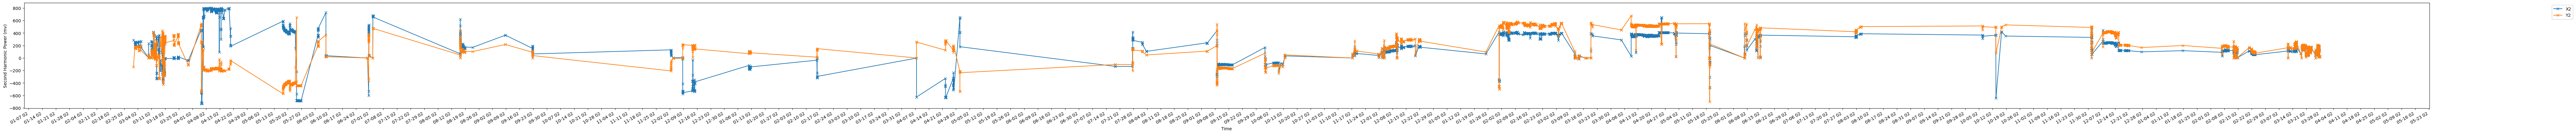

In [46]:
plt.figure(figsize=(100, 5))
sagn.plot_power_for_df( all_history,hrsPerTick=168)
# plt.savefig("all_power.jpg")

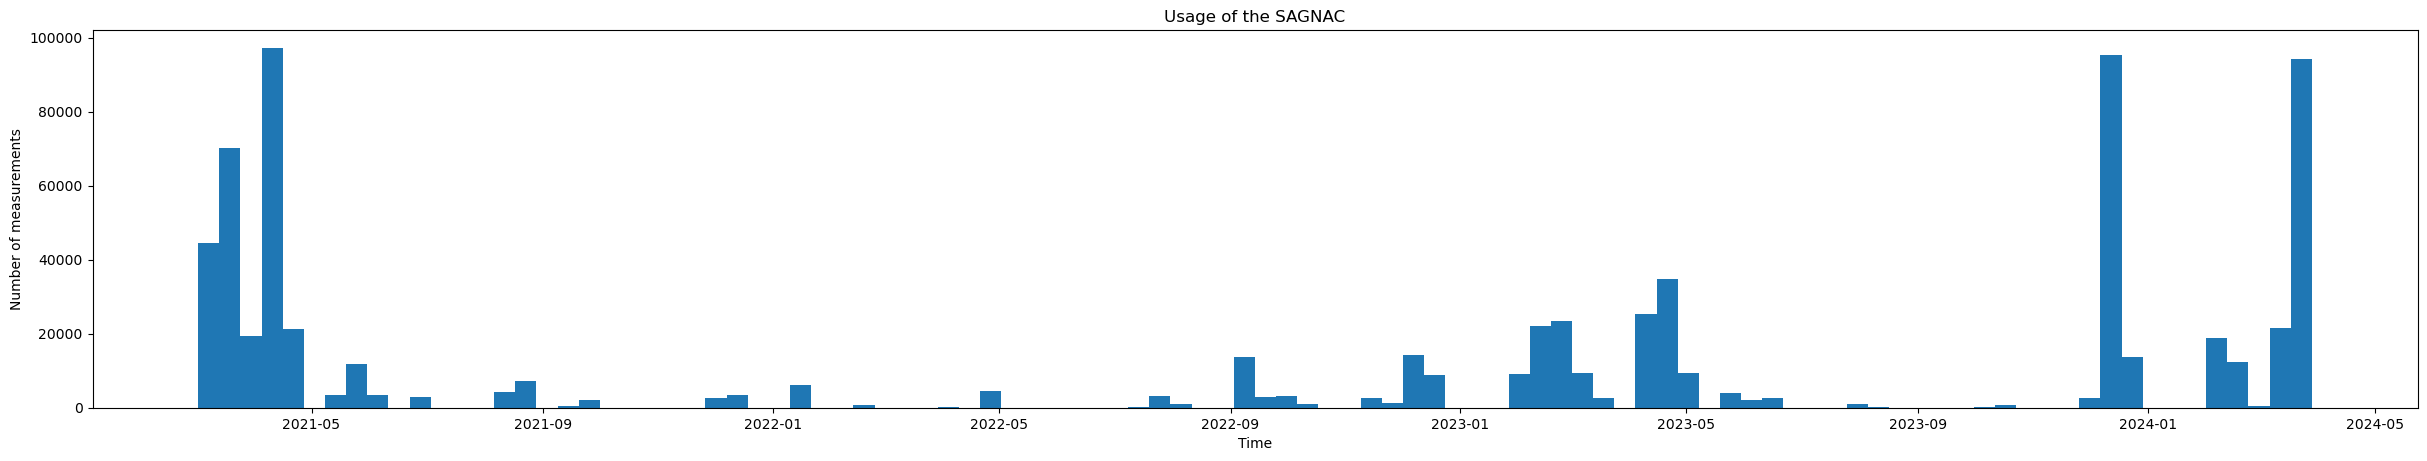

In [111]:
plt.figure(figsize=(30, 5))
plt.hist(pd.to_datetime(all_history.timeModified, unit='s'), bins=100)
plt.xlabel('Time')
plt.ylabel('Number of measurements')
plt.title('Usage of the SAGNAC')
plt.show()

groupname is 0, with 134260 entries
groupname is 1, with 118383 entries
groupname is 2, with 15277 entries
groupname is 3, with 3484 entries
groupname is 4, with 3018 entries
groupname is 5, with 11305 entries
groupname is 6, with 534 entries
groupname is 7, with 2046 entries
groupname is 8, with 5996 entries
groupname is 9, with 6198 entries
groupname is 10, with 661 entries
groupname is 11, with 183 entries
groupname is 12, with 4418 entries
groupname is 13, with 164 entries
groupname is 14, with 4165 entries
groupname is 15, with 1249 entries
groupname is 16, with 15539 entries
groupname is 17, with 4306 entries
groupname is 18, with 2593 entries
groupname is 19, with 24288 entries
groupname is 20, with 41 entries
groupname is 21, with 62812 entries


<ipython-input-128-d01563fecb48>:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(30, 5))


groupname is 22, with 3892 entries
groupname is 23, with 290 entries
groupname is 24, with 69304 entries
groupname is 25, with 4075 entries
groupname is 26, with 4681 entries
groupname is 27, with 1247 entries
groupname is 28, with 246 entries
groupname is 29, with 603 entries
groupname is 30, with 2625 entries
groupname is 31, with 108977 entries
groupname is 32, with 122 entries
groupname is 33, with 42 entries
groupname is 34, with 27960 entries
groupname is 35, with 3808 entries
groupname is 36, with 115812 entries


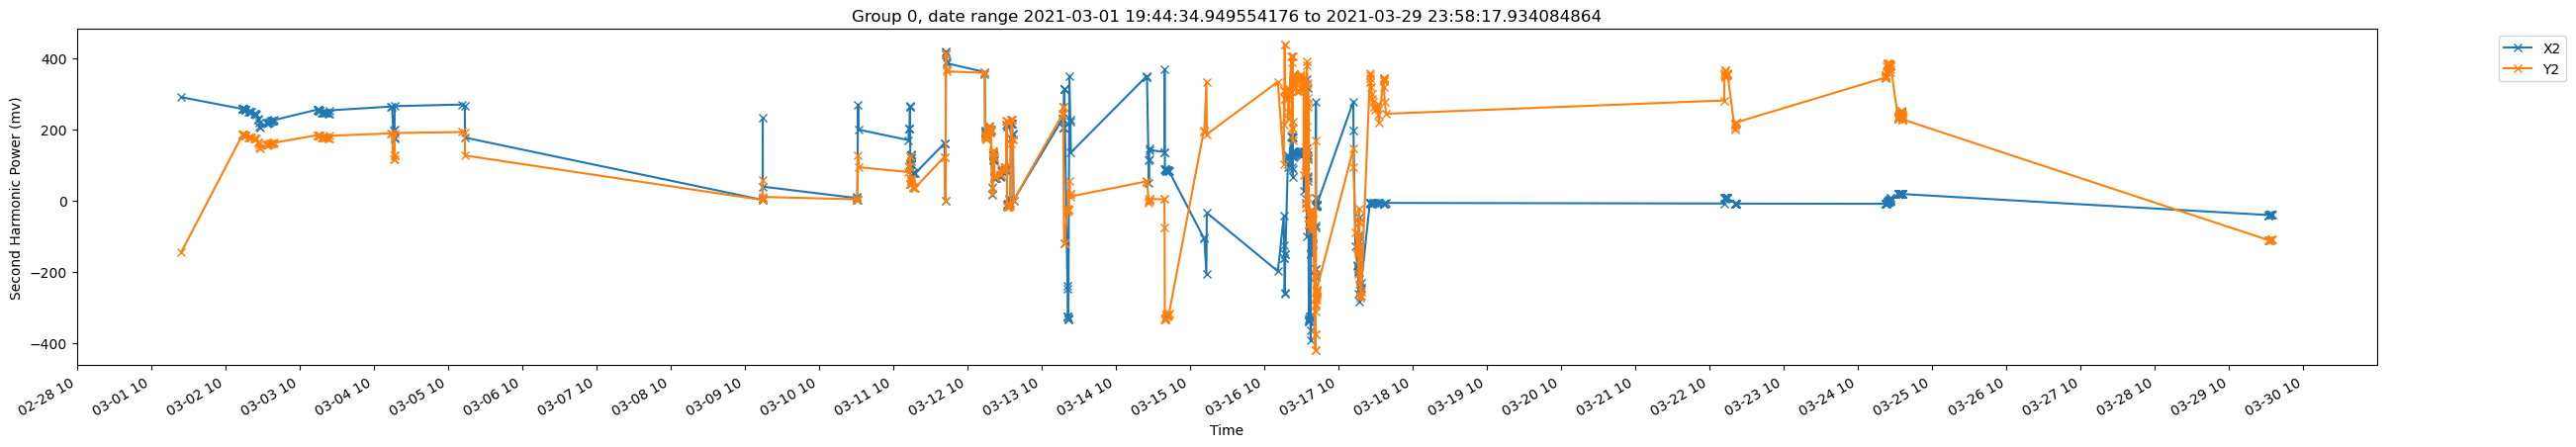

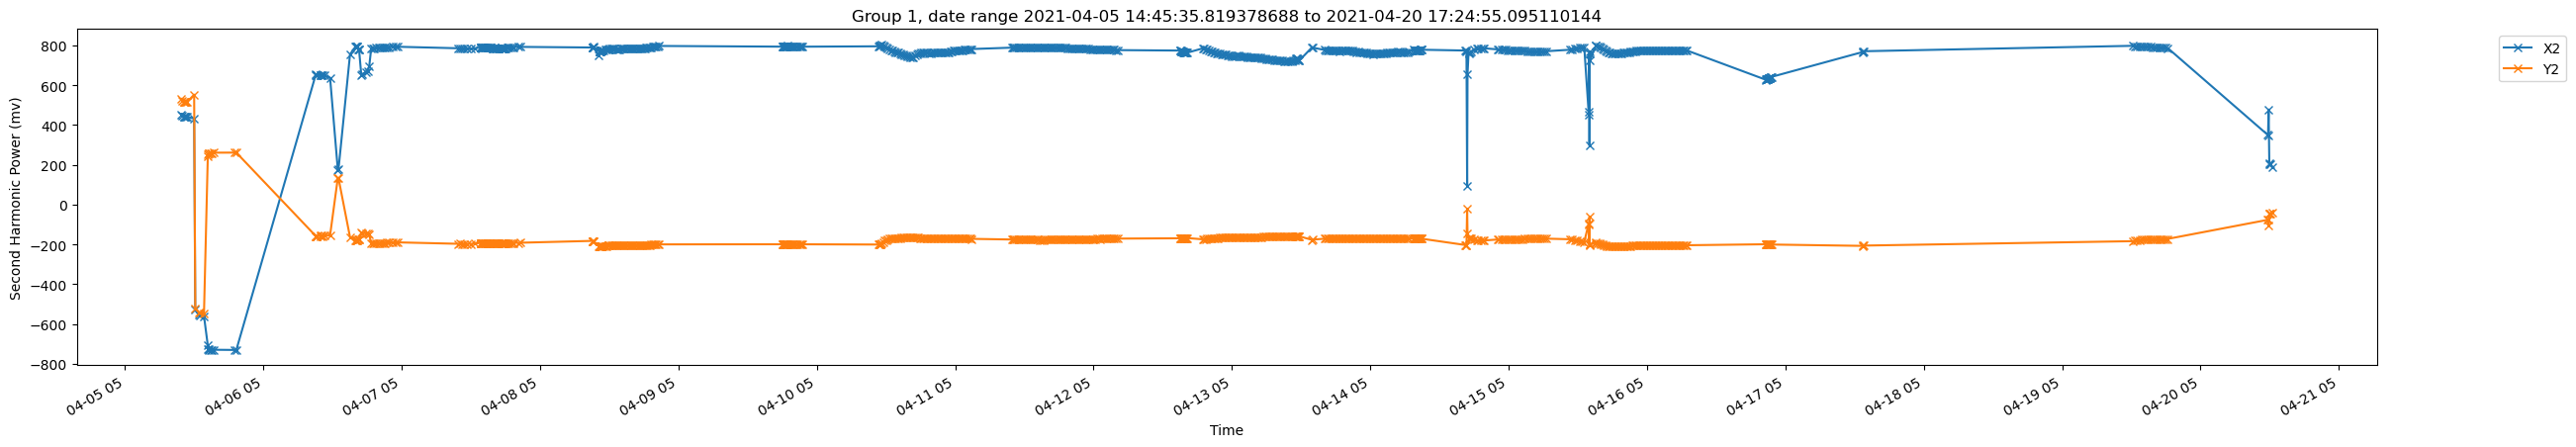

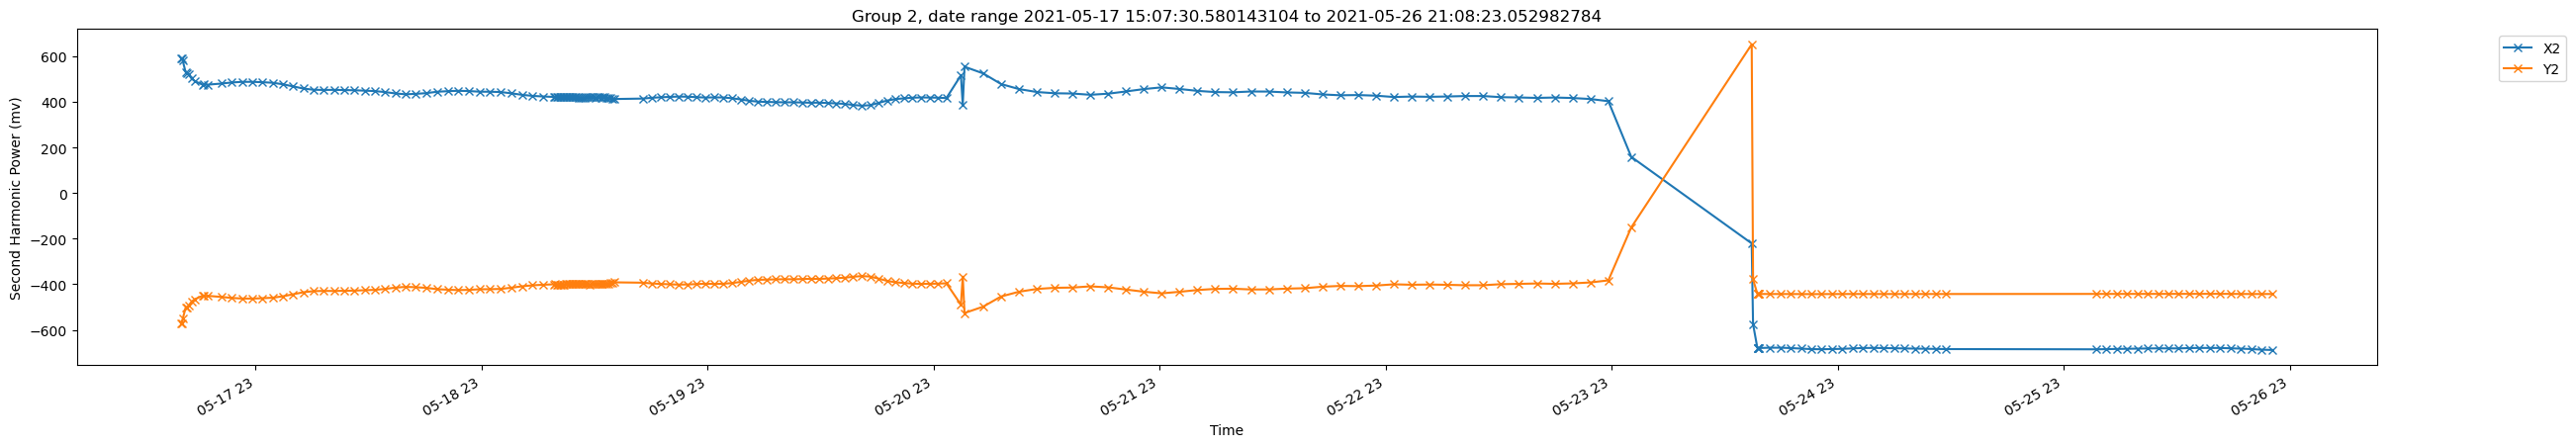

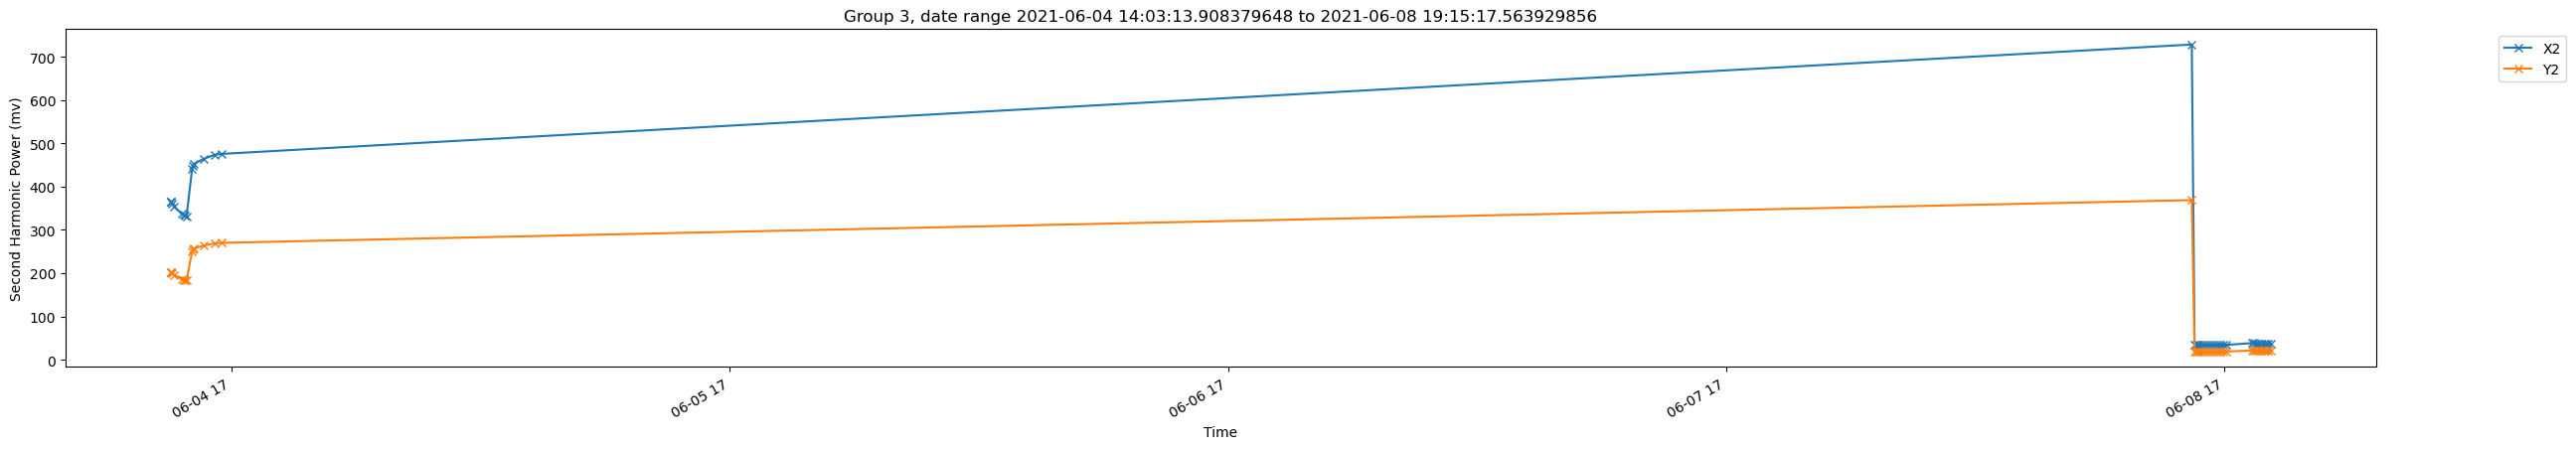

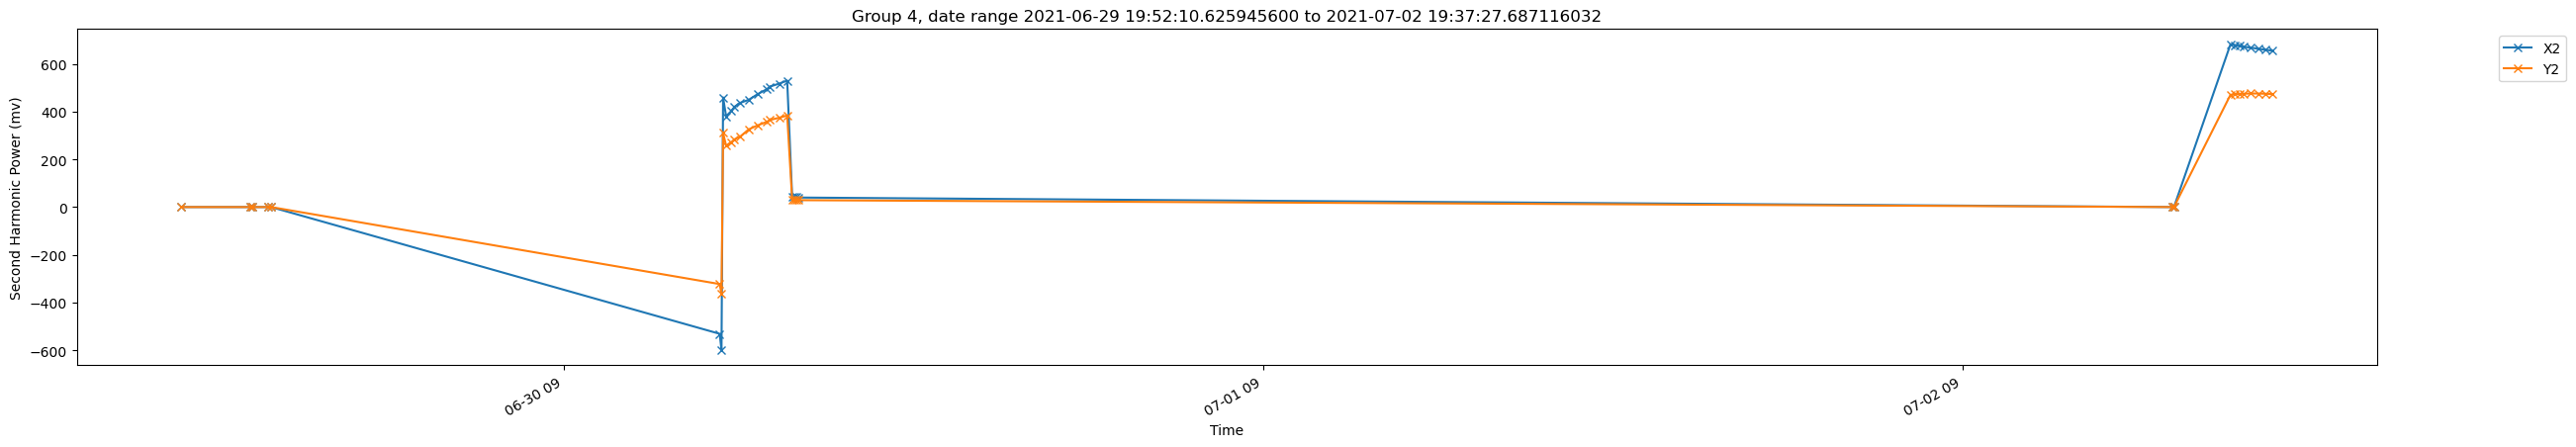

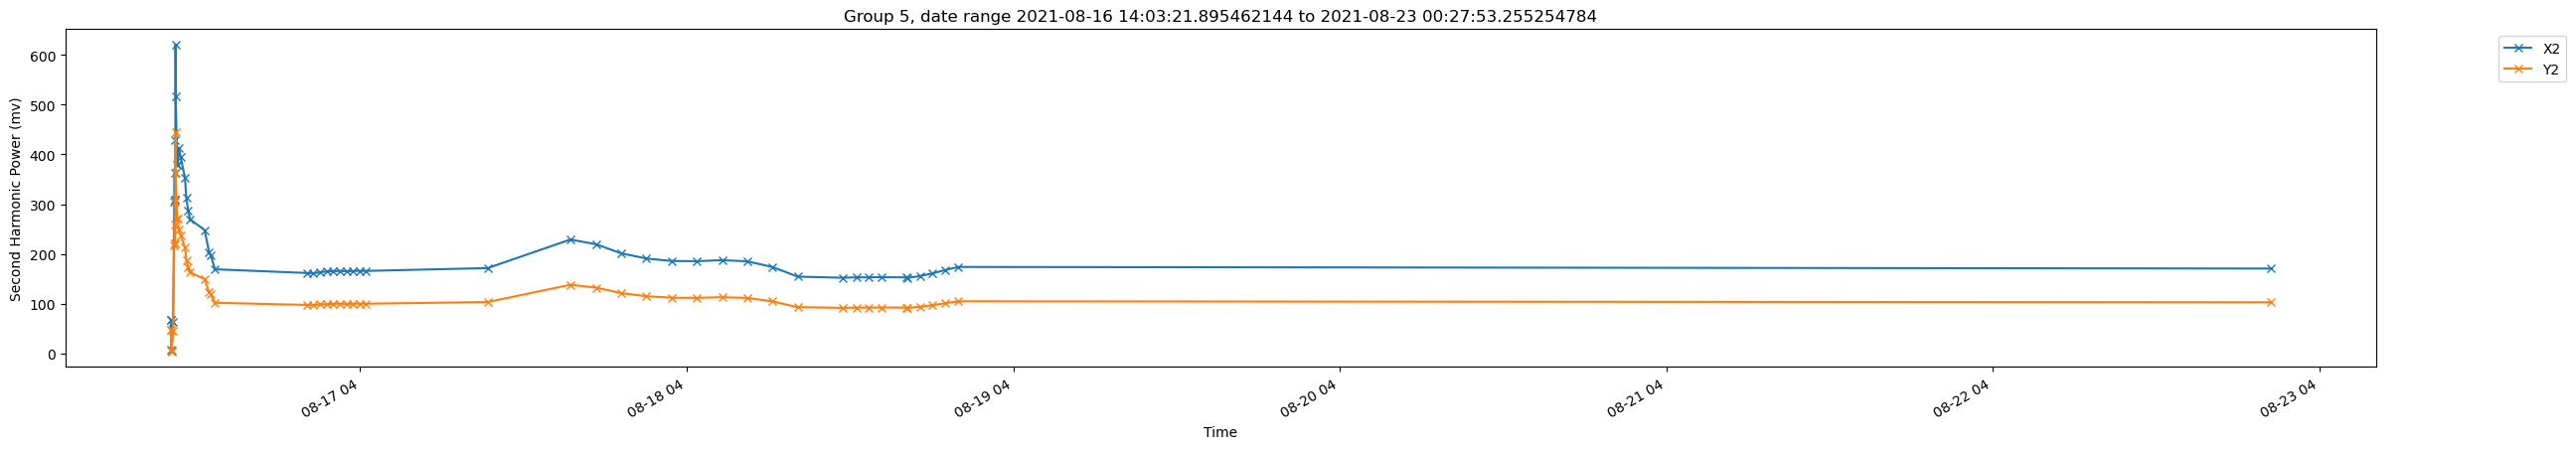

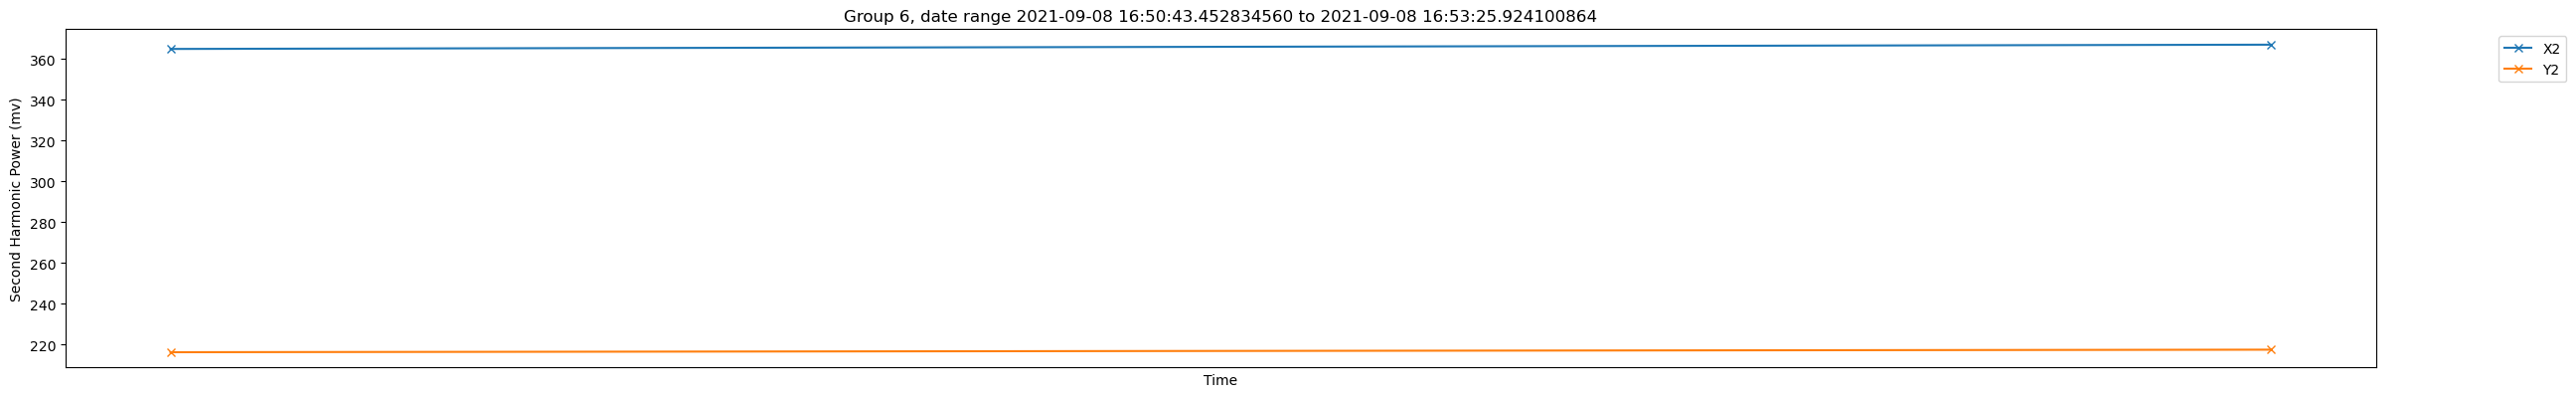

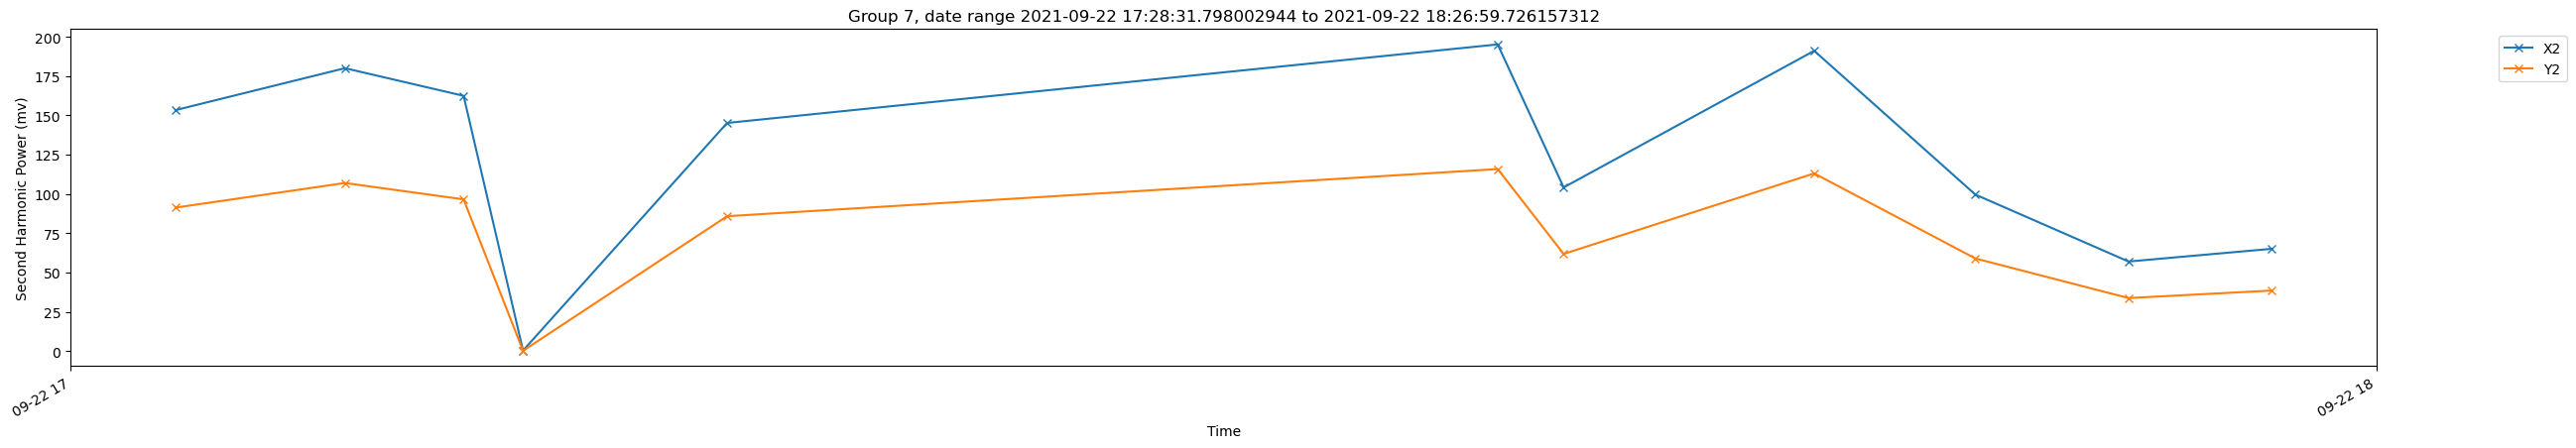

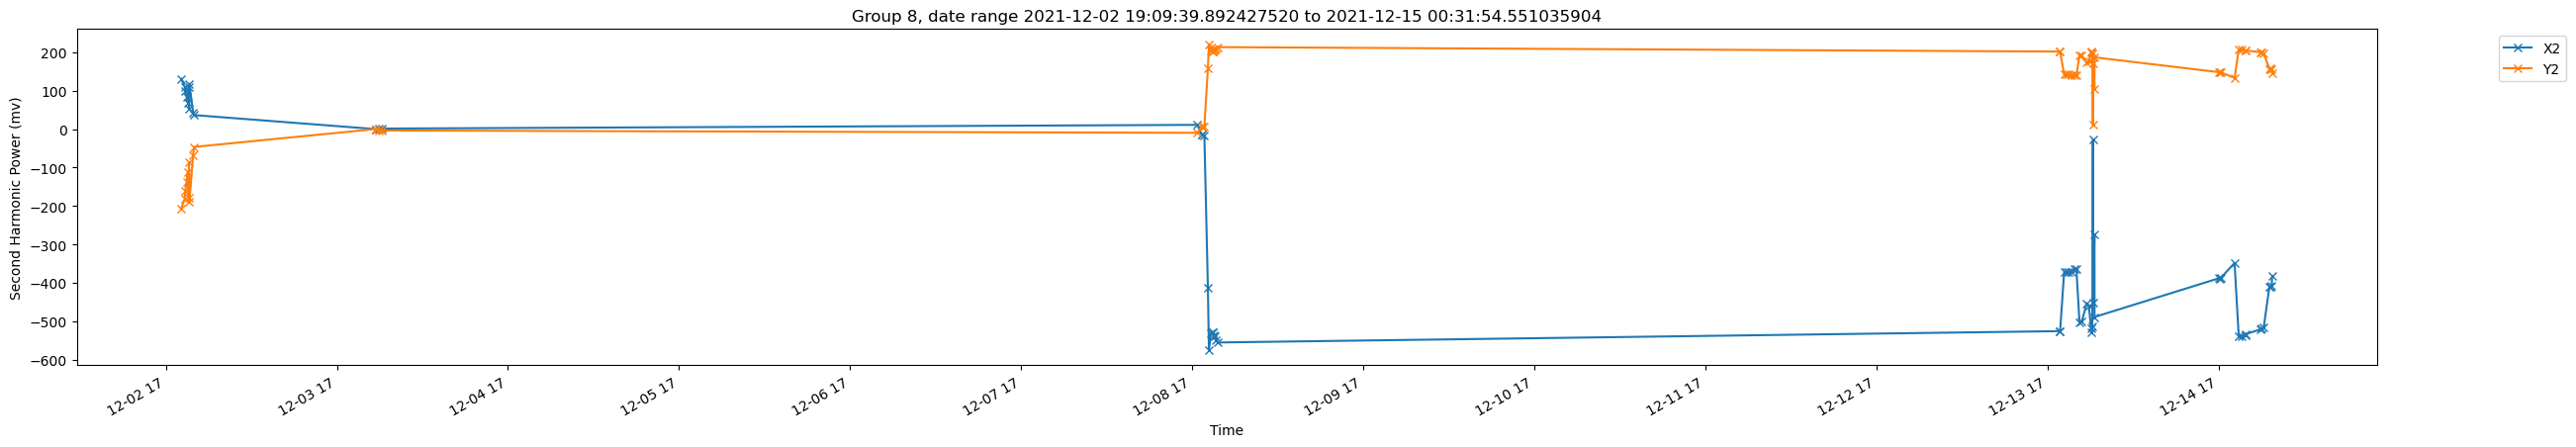

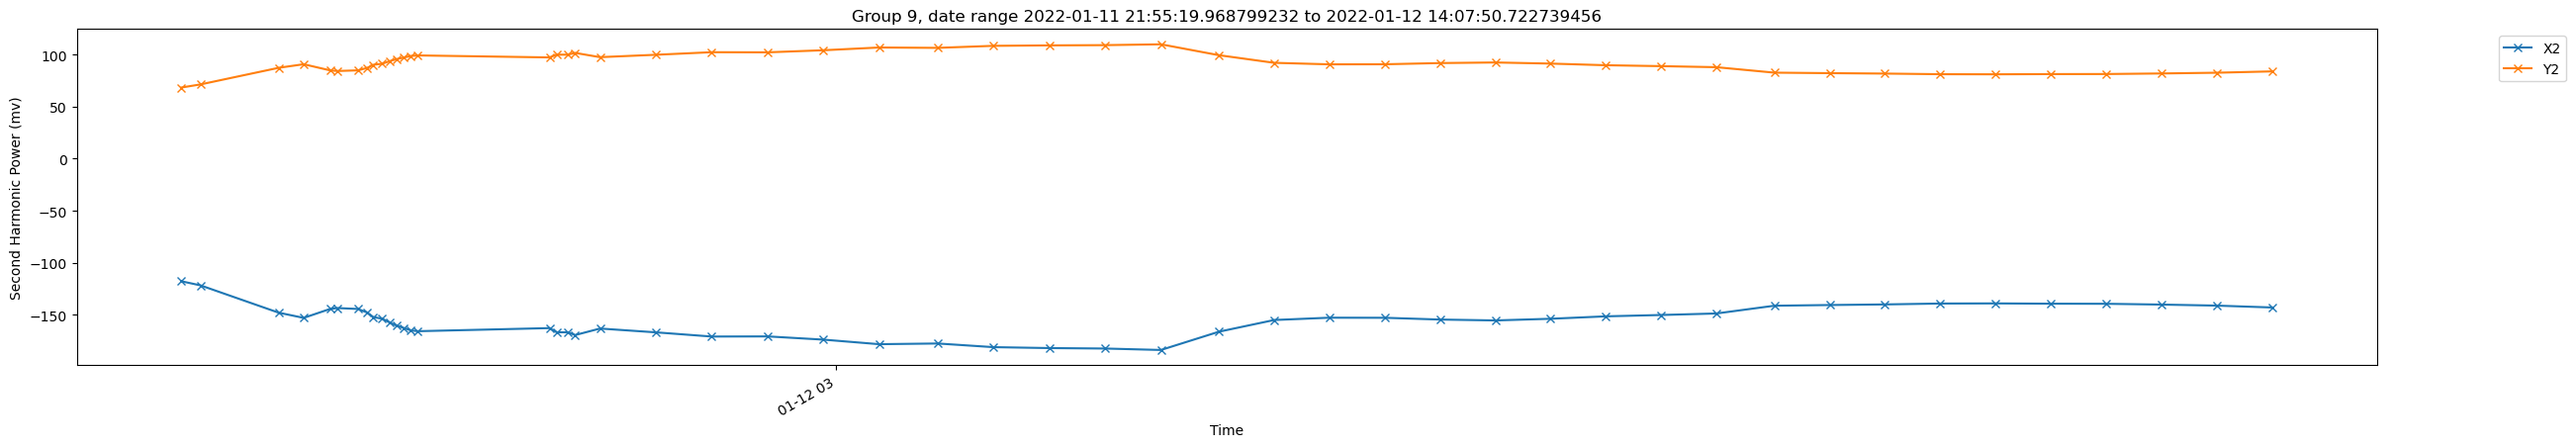

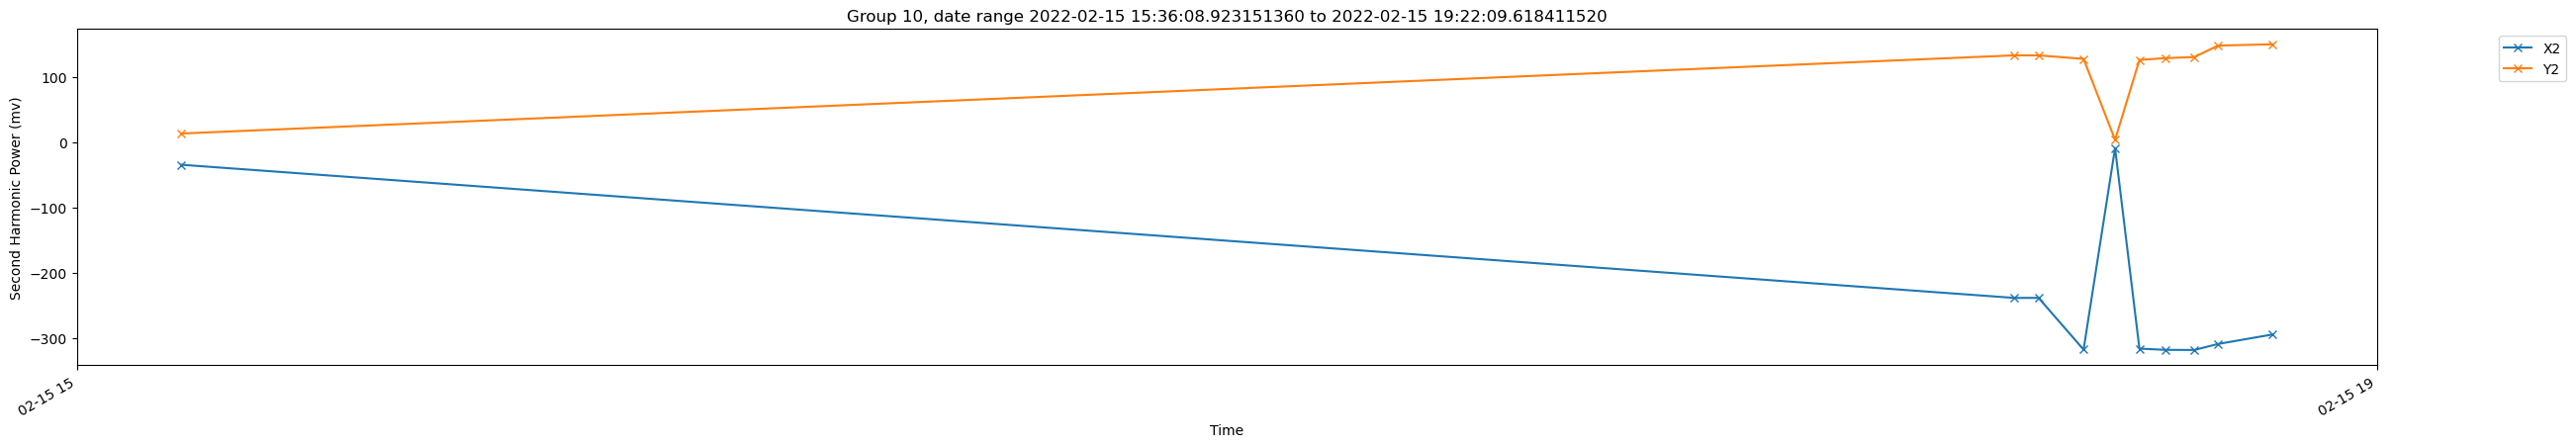

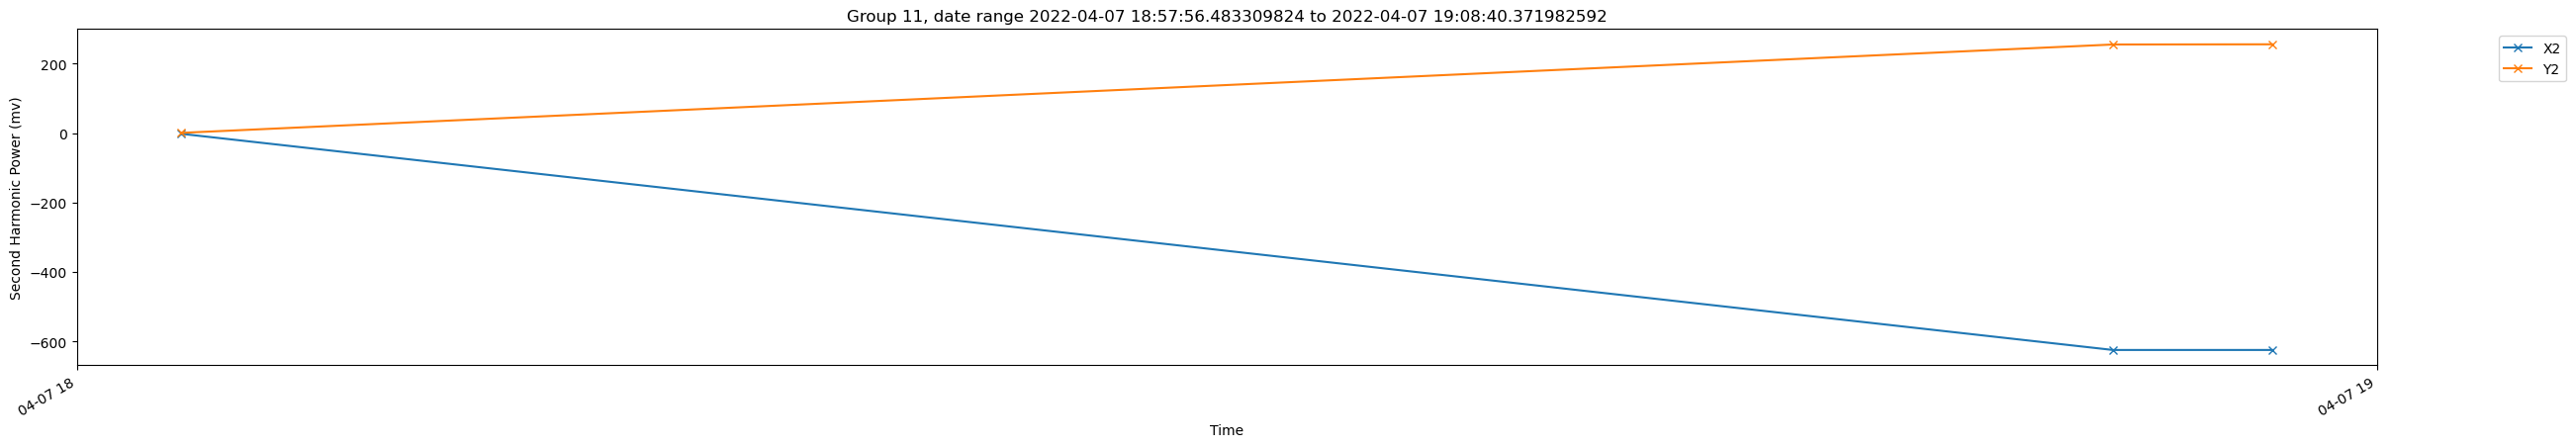

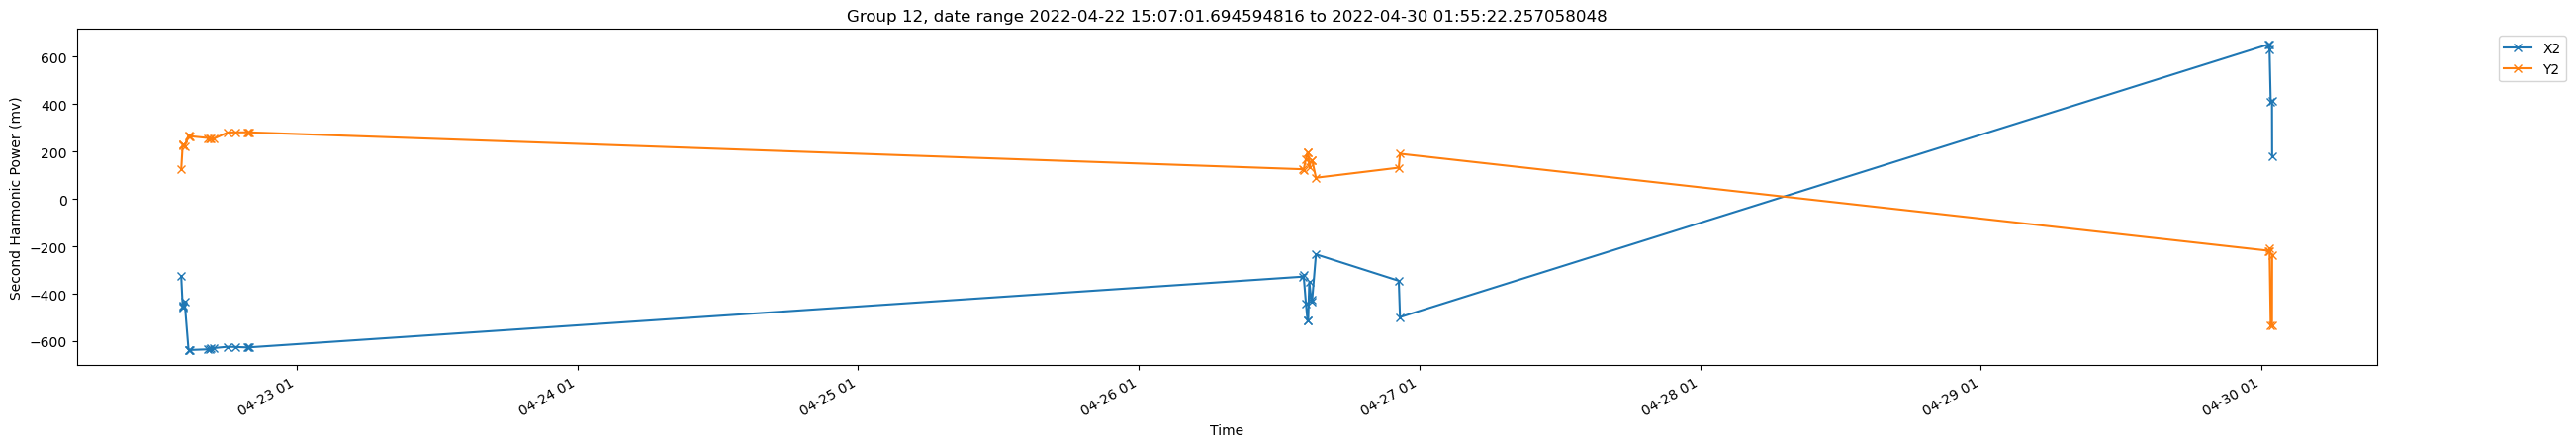

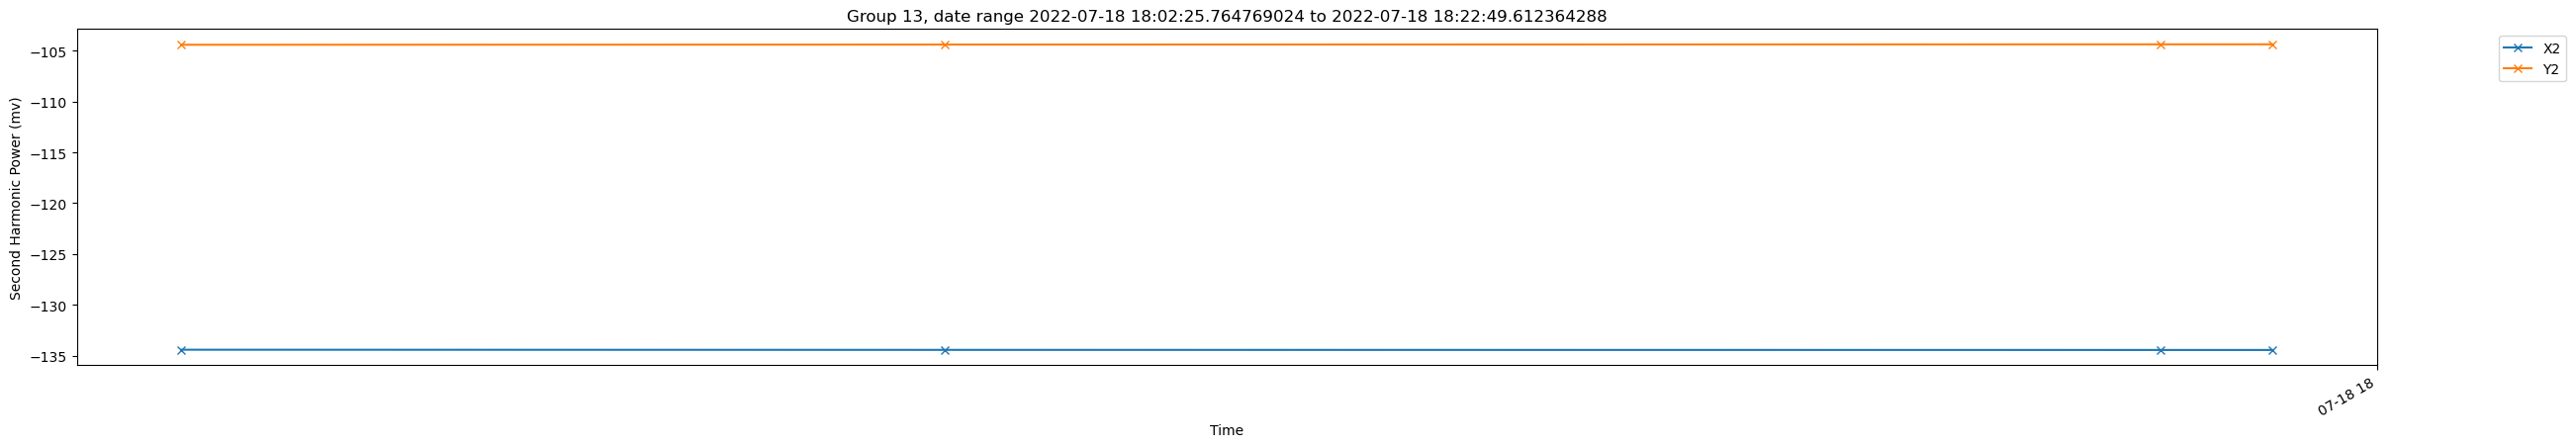

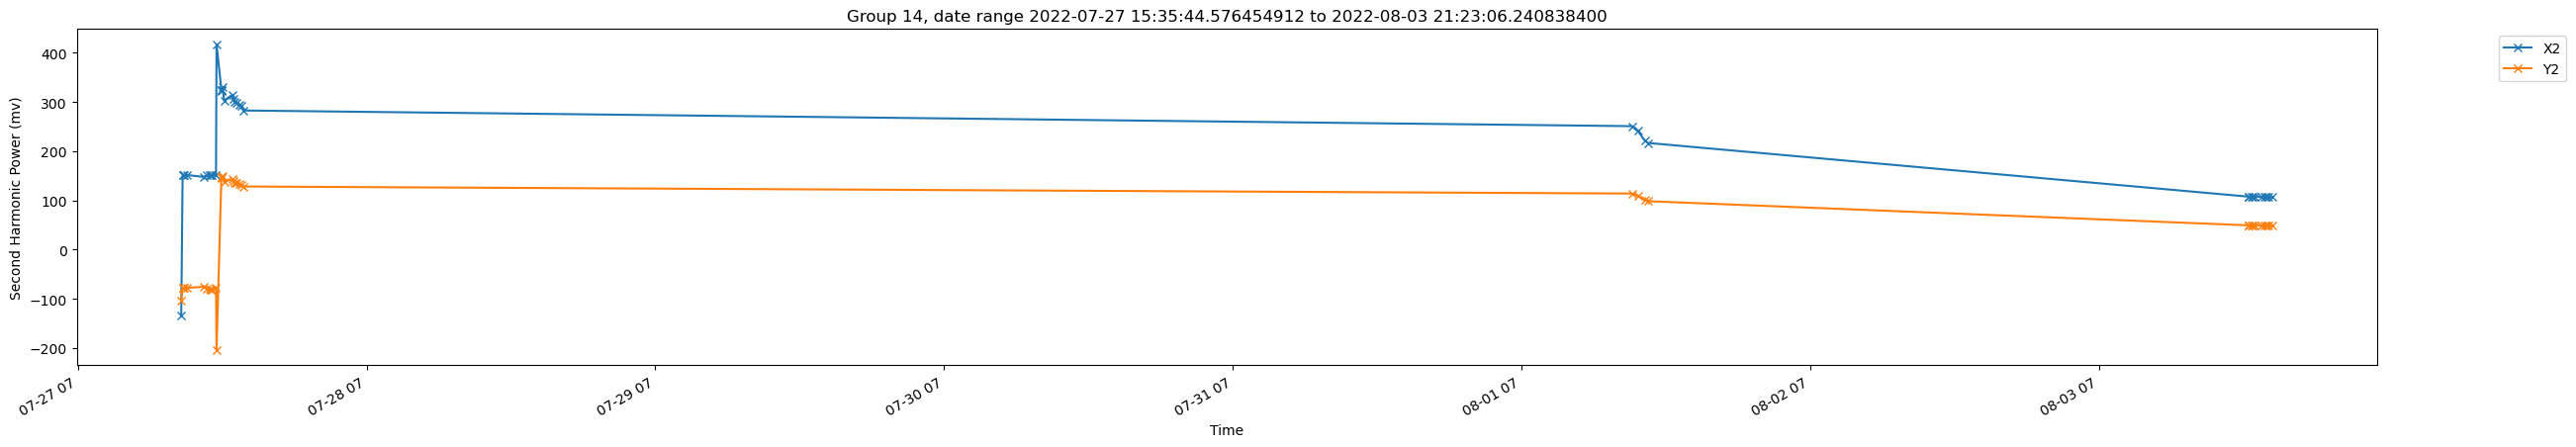

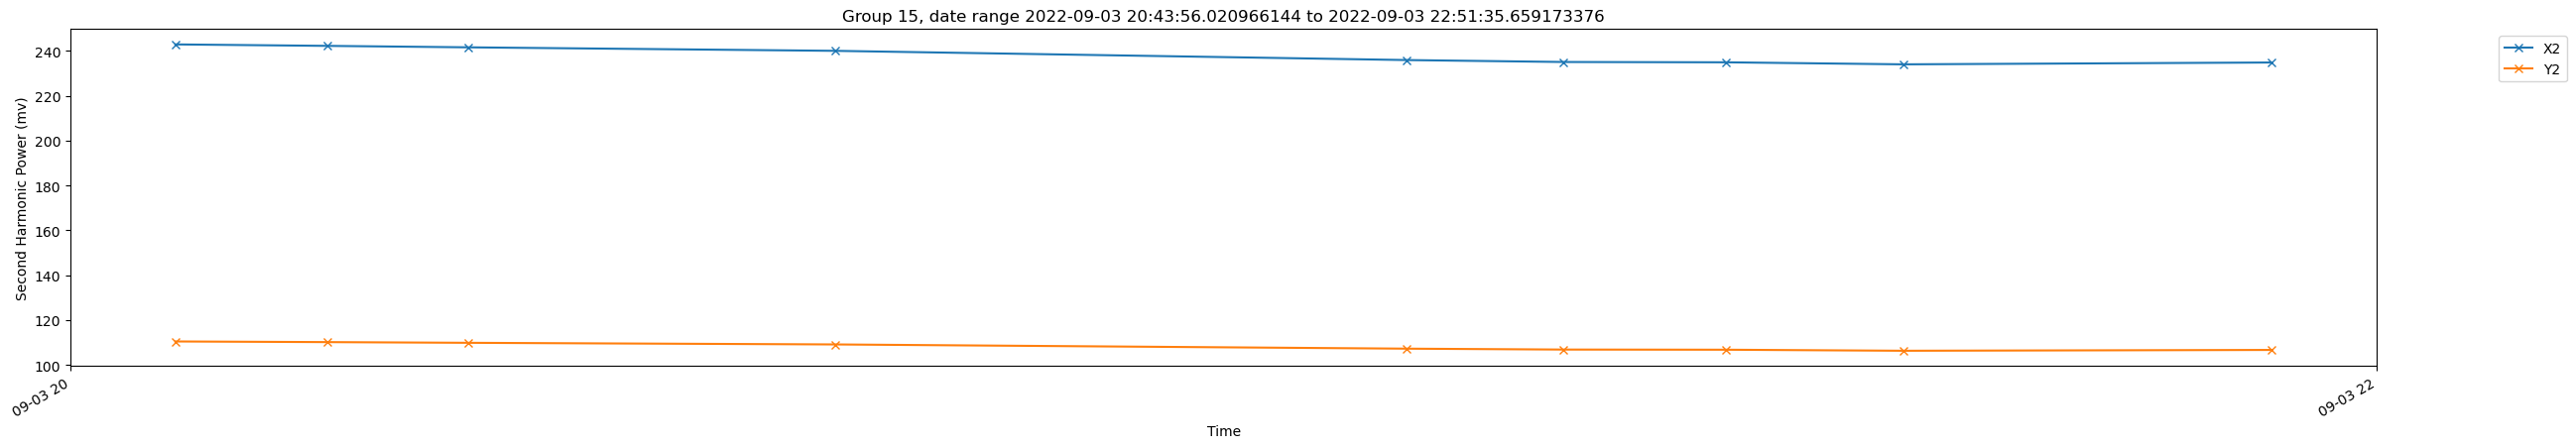

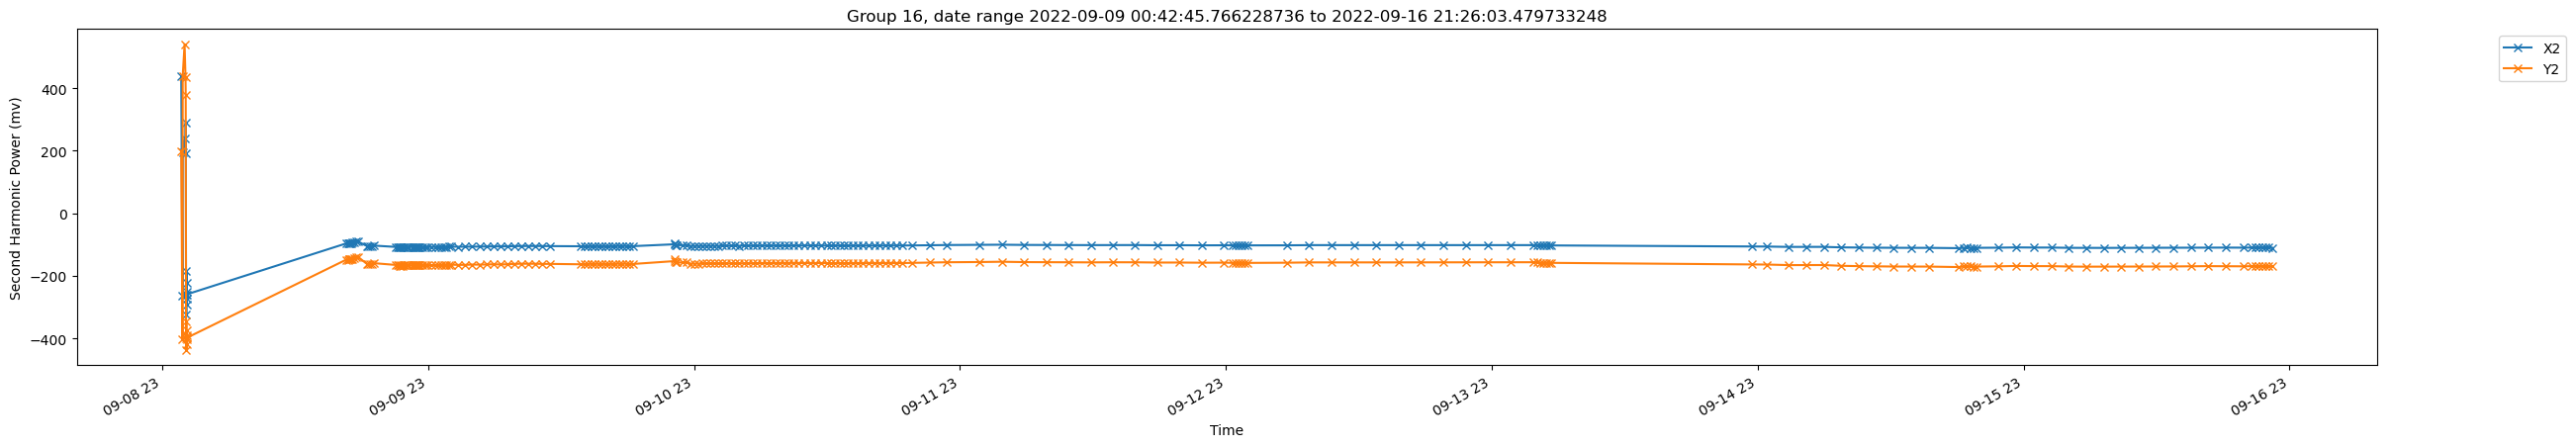

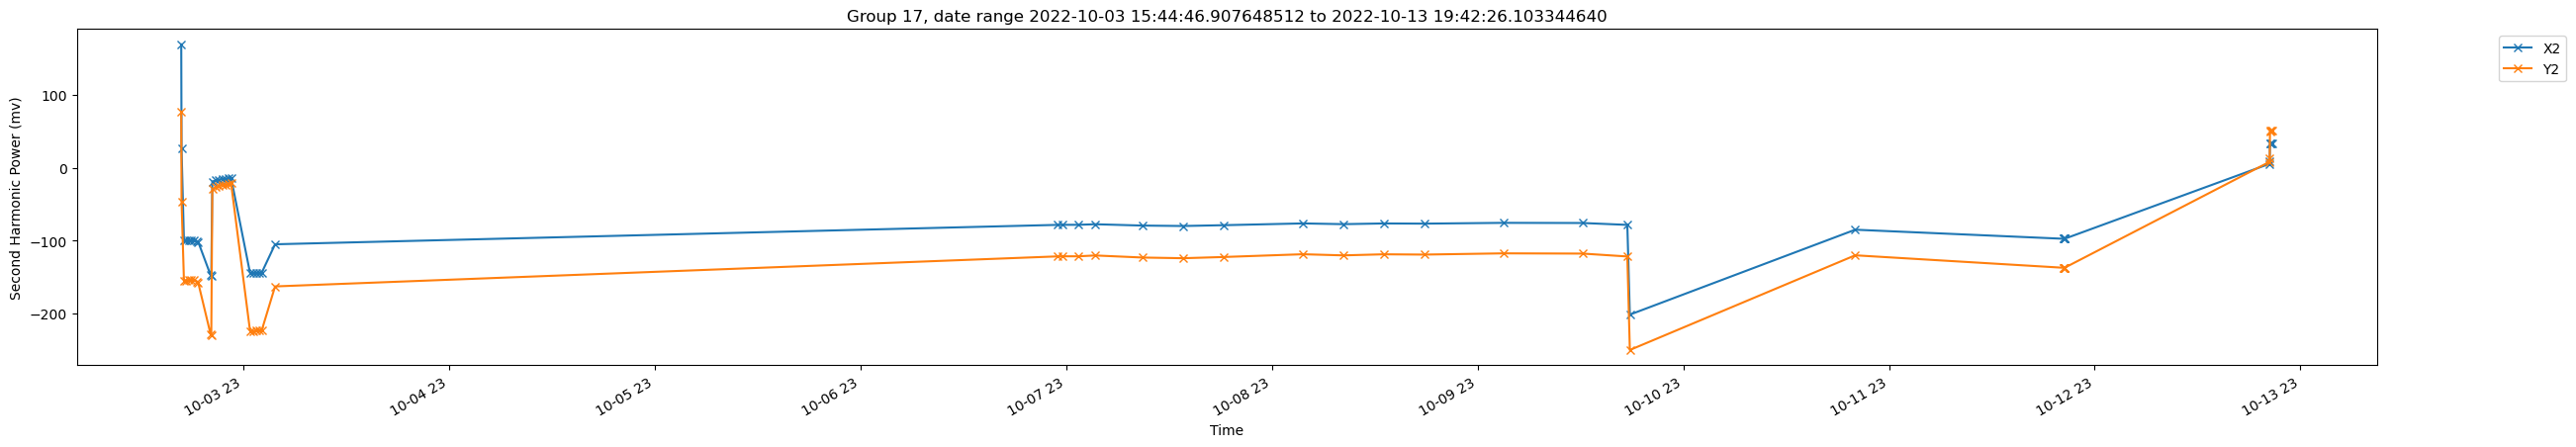

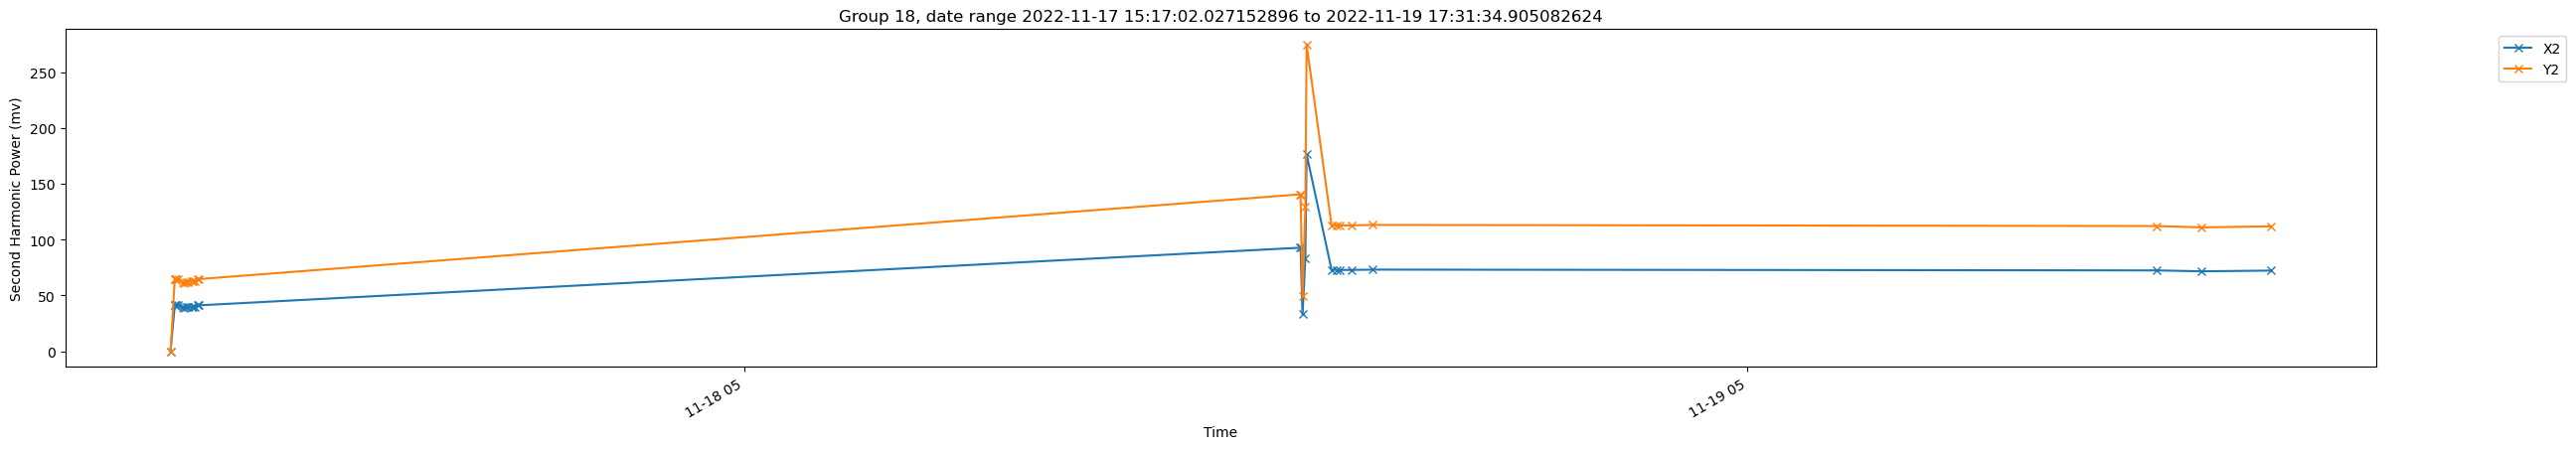

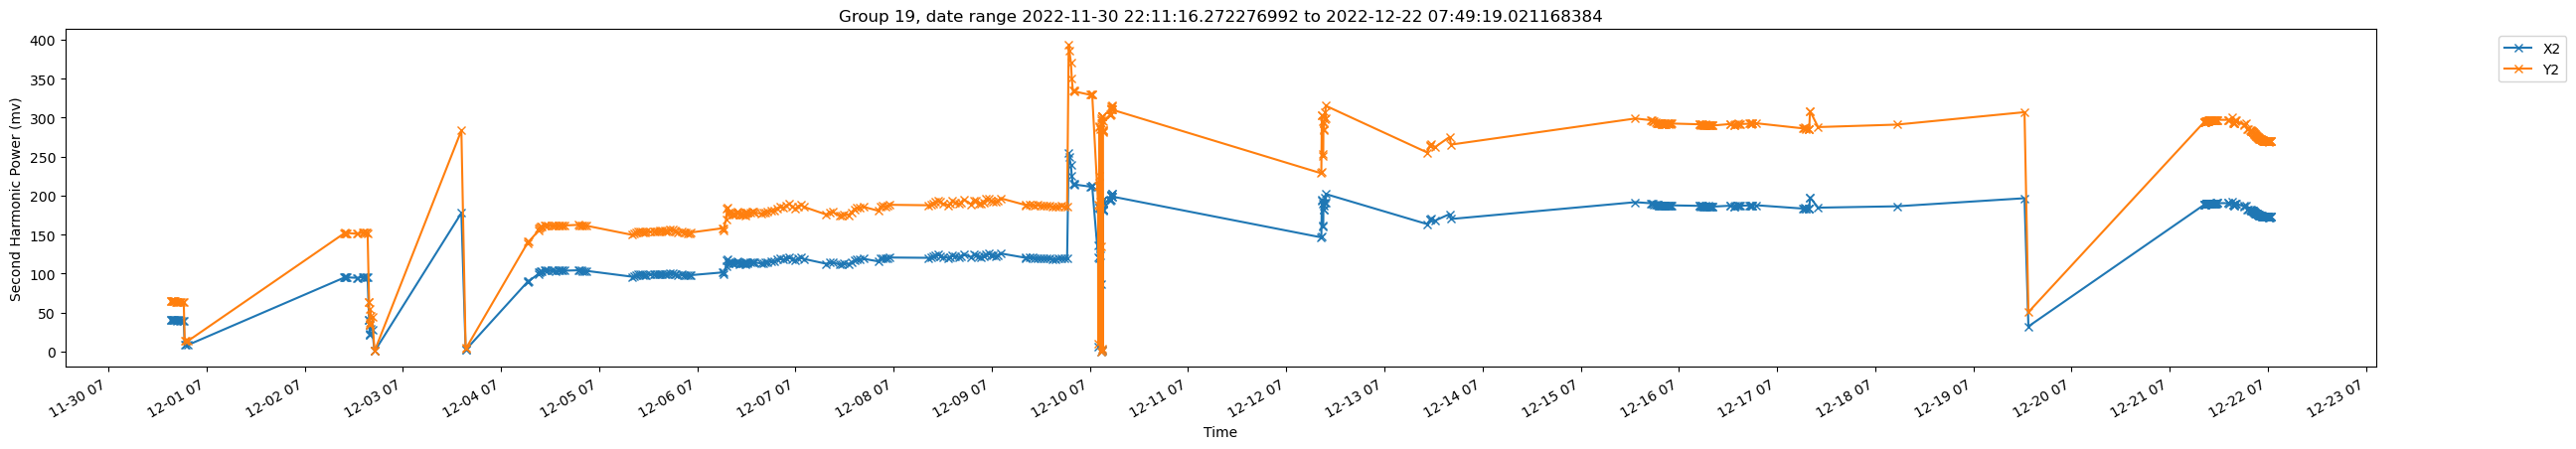

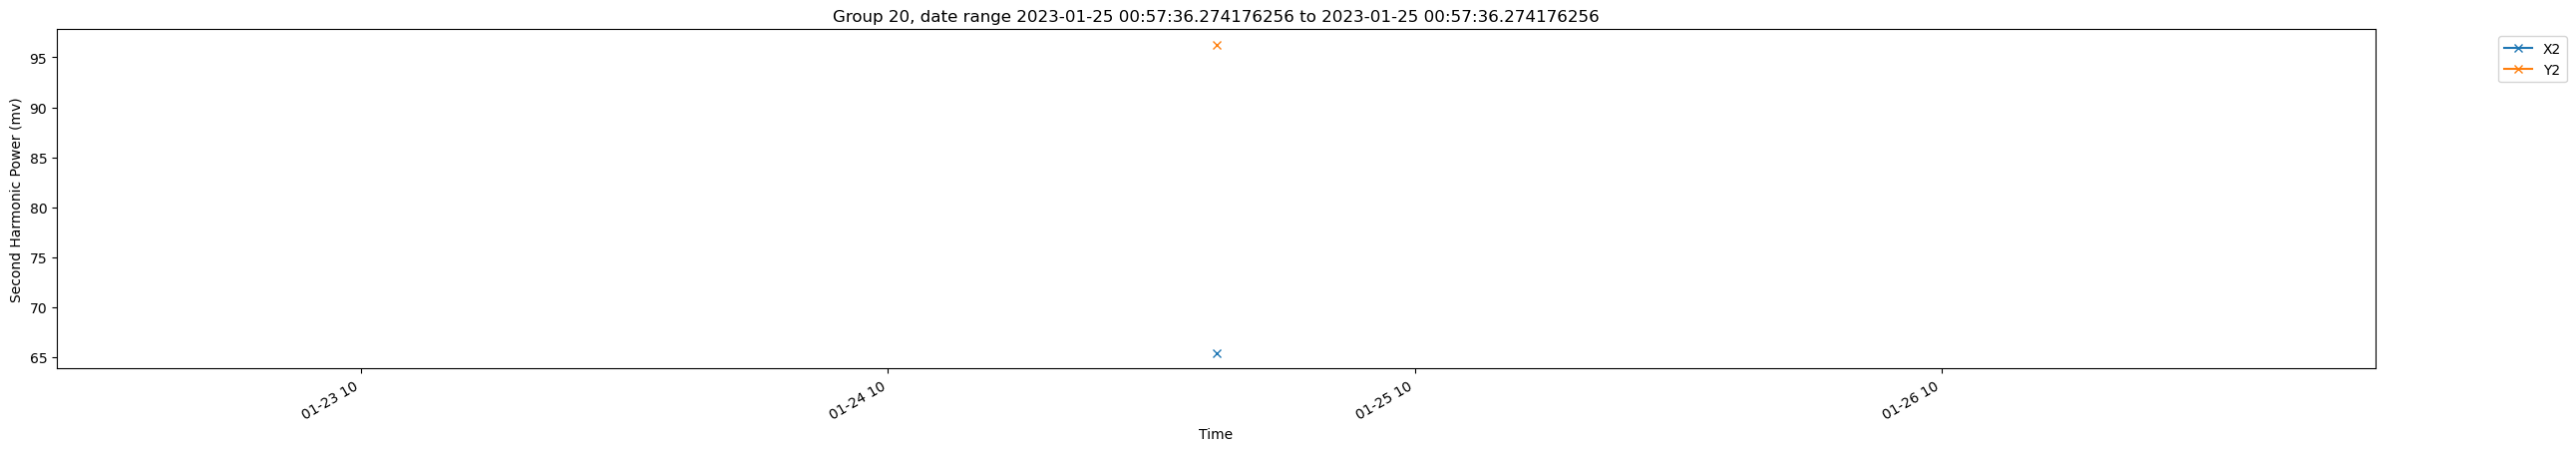

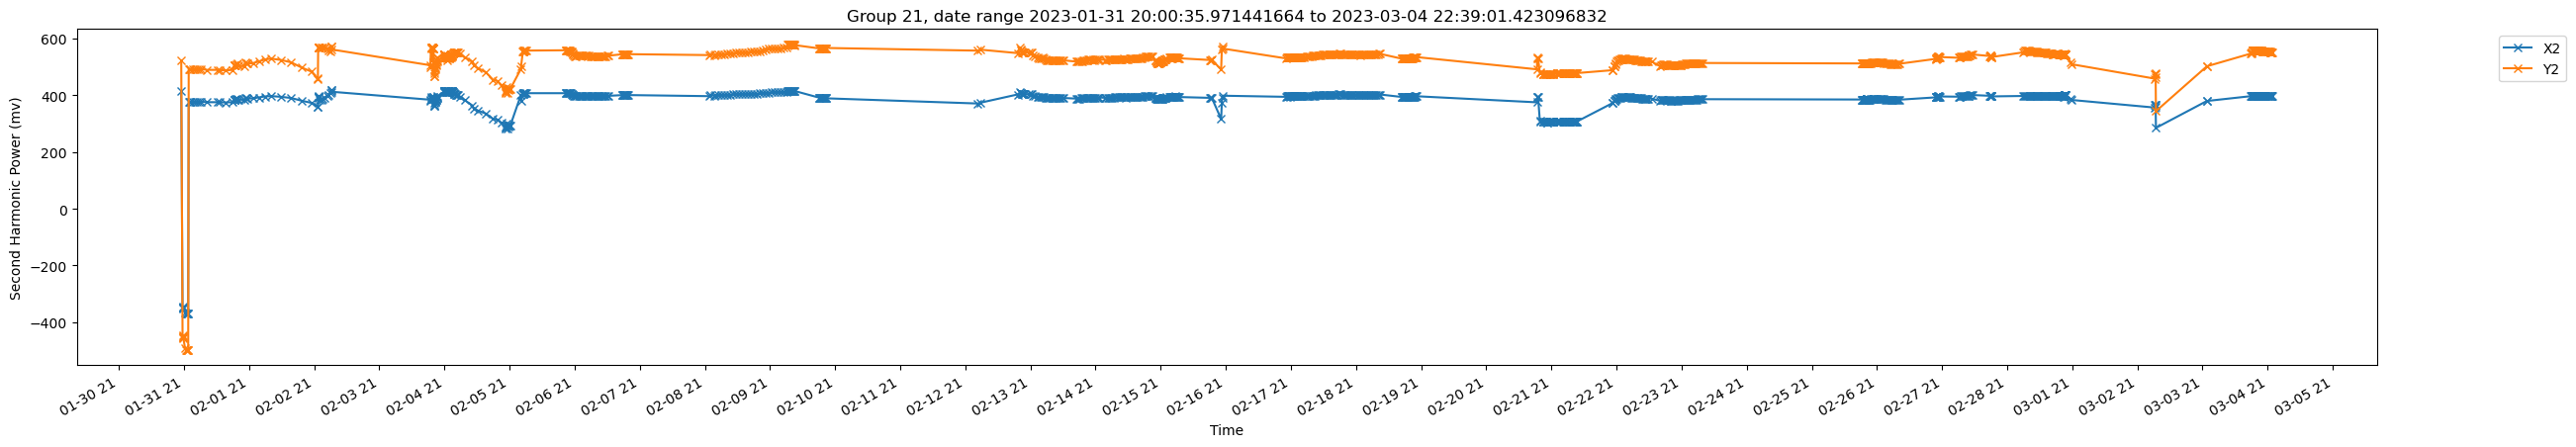

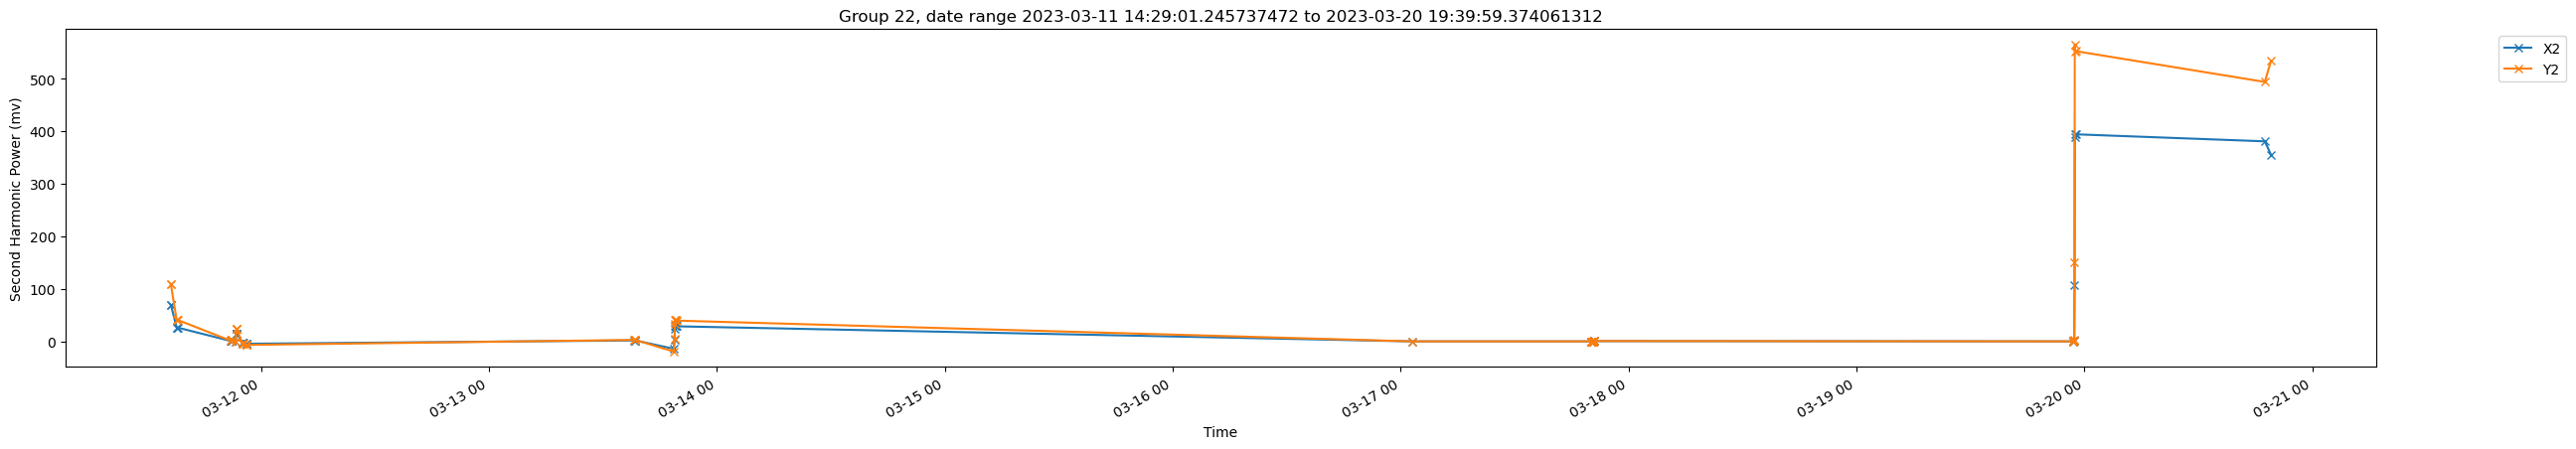

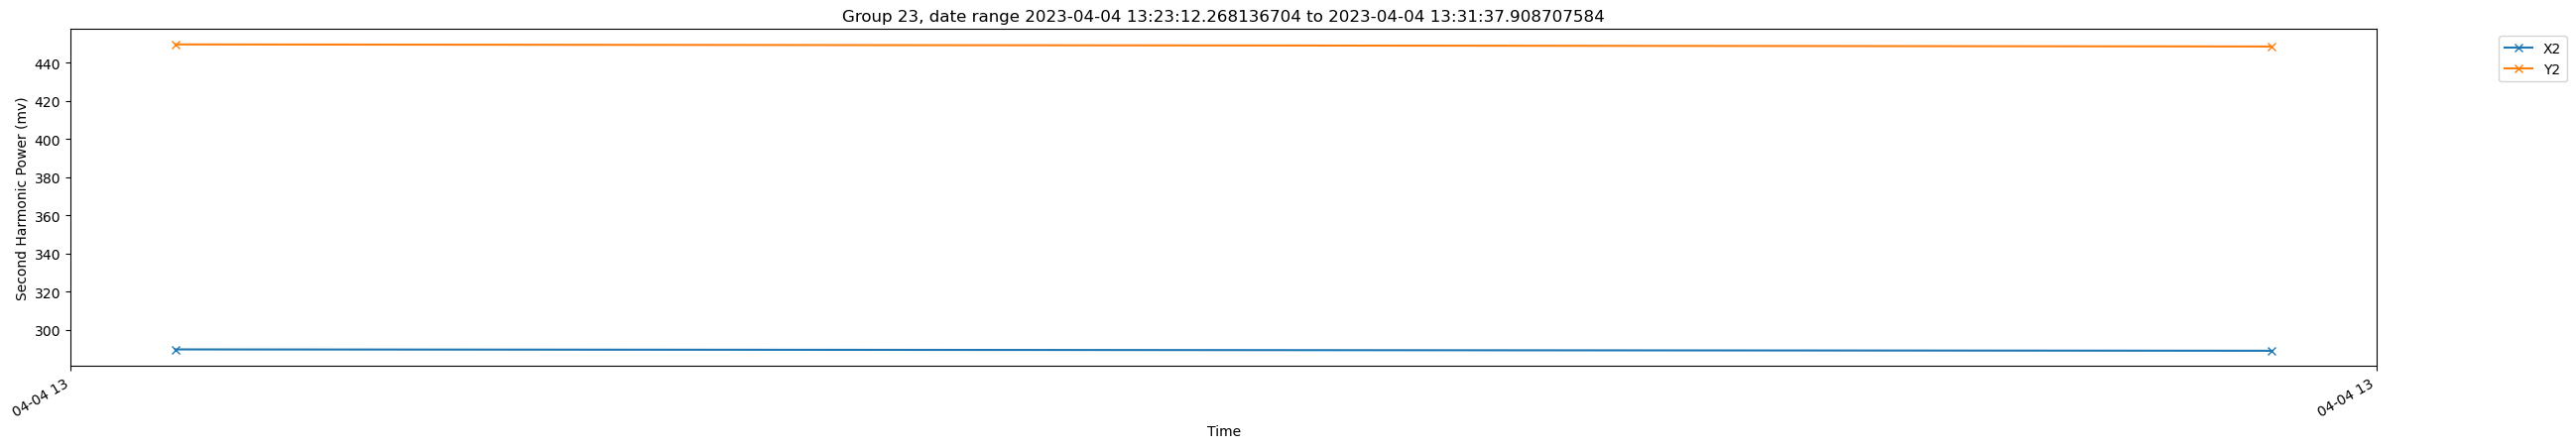

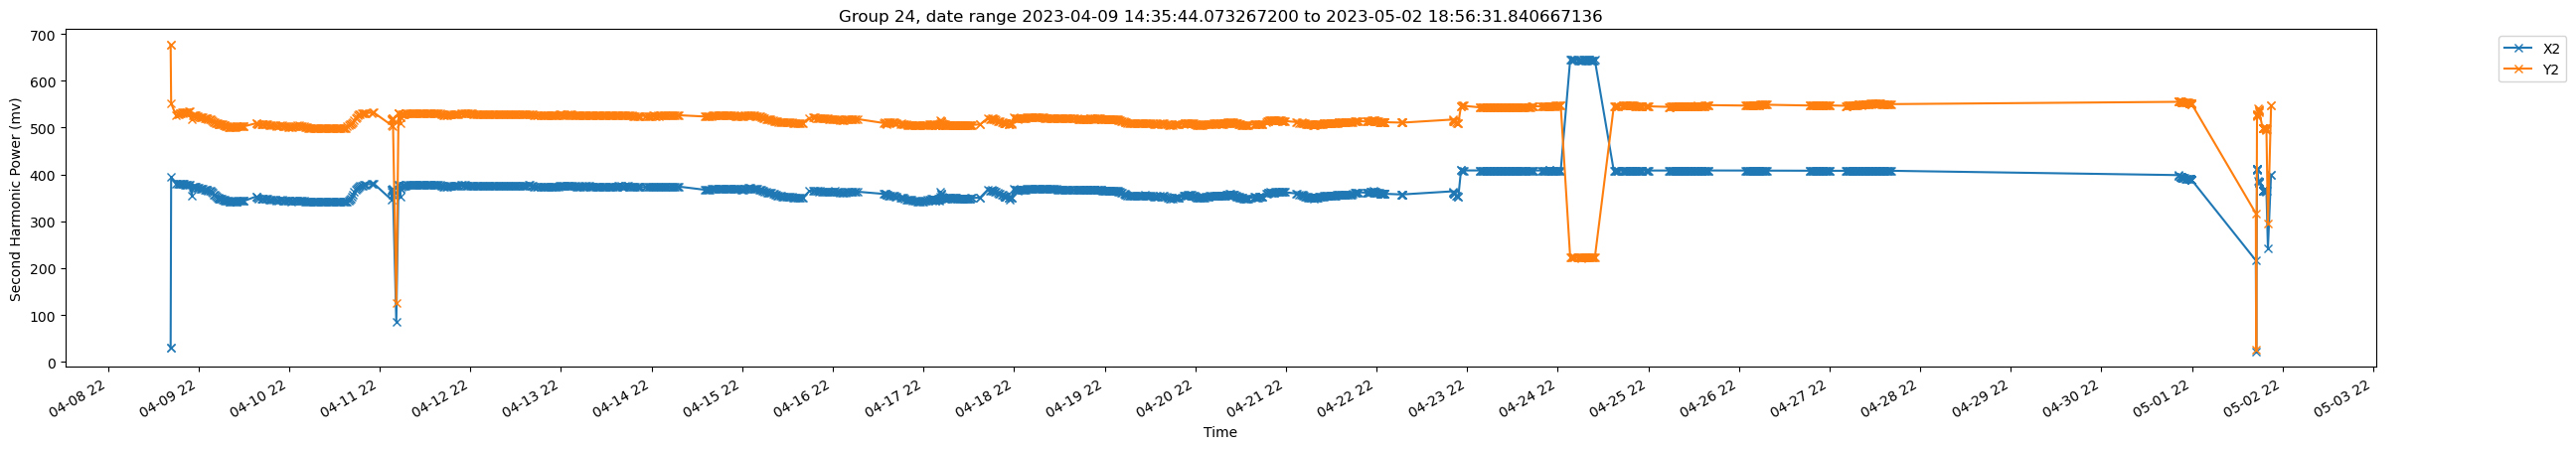

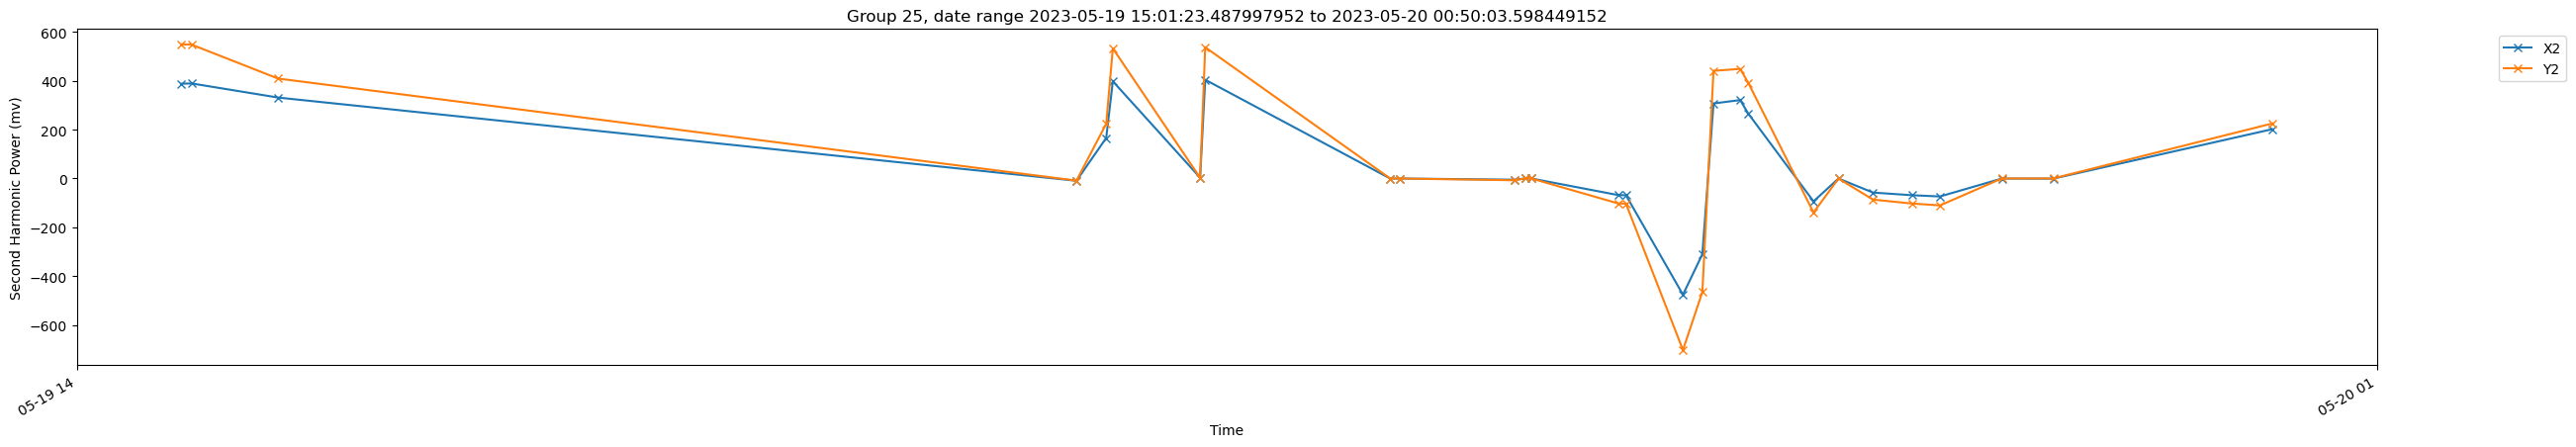

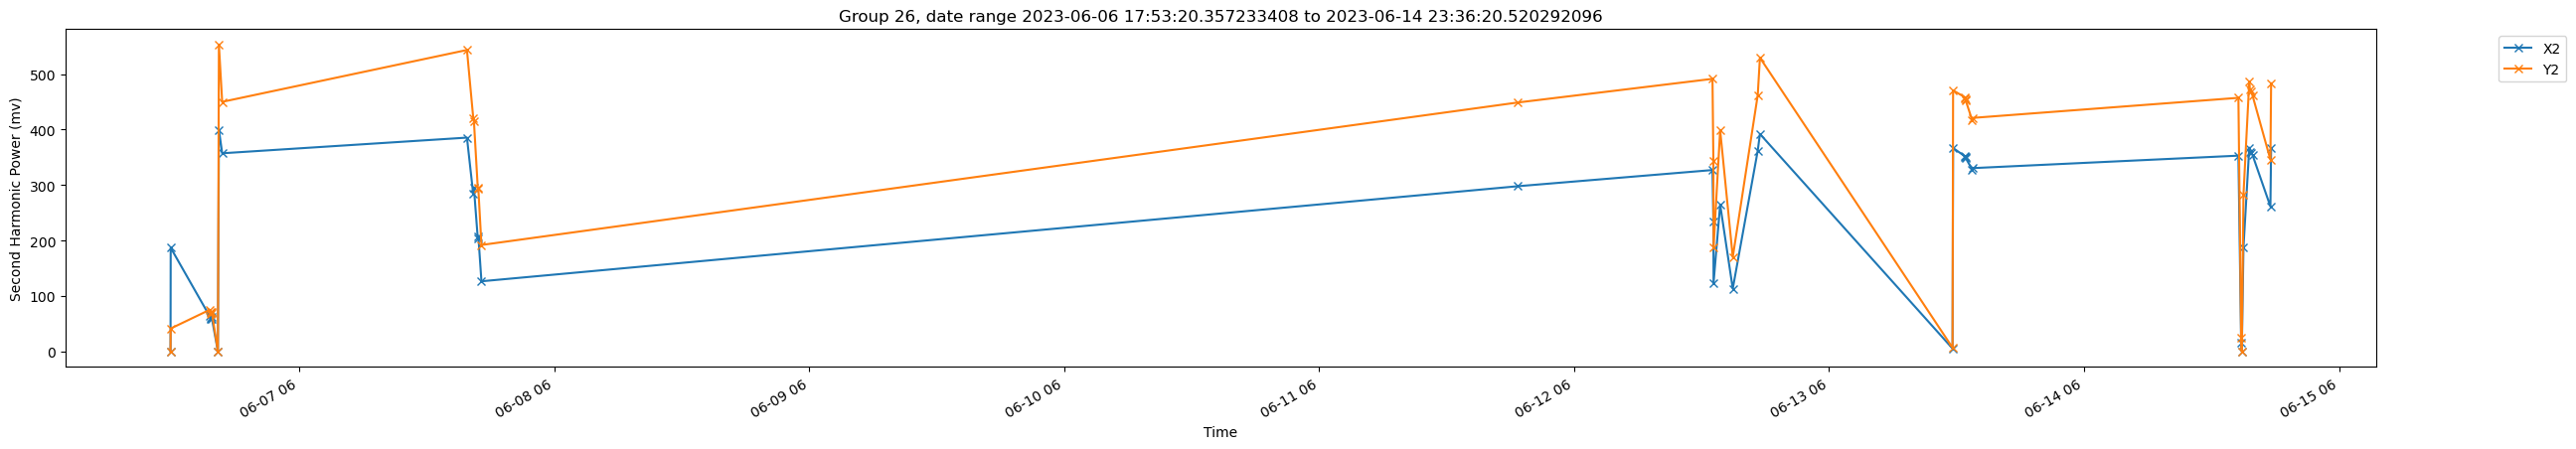

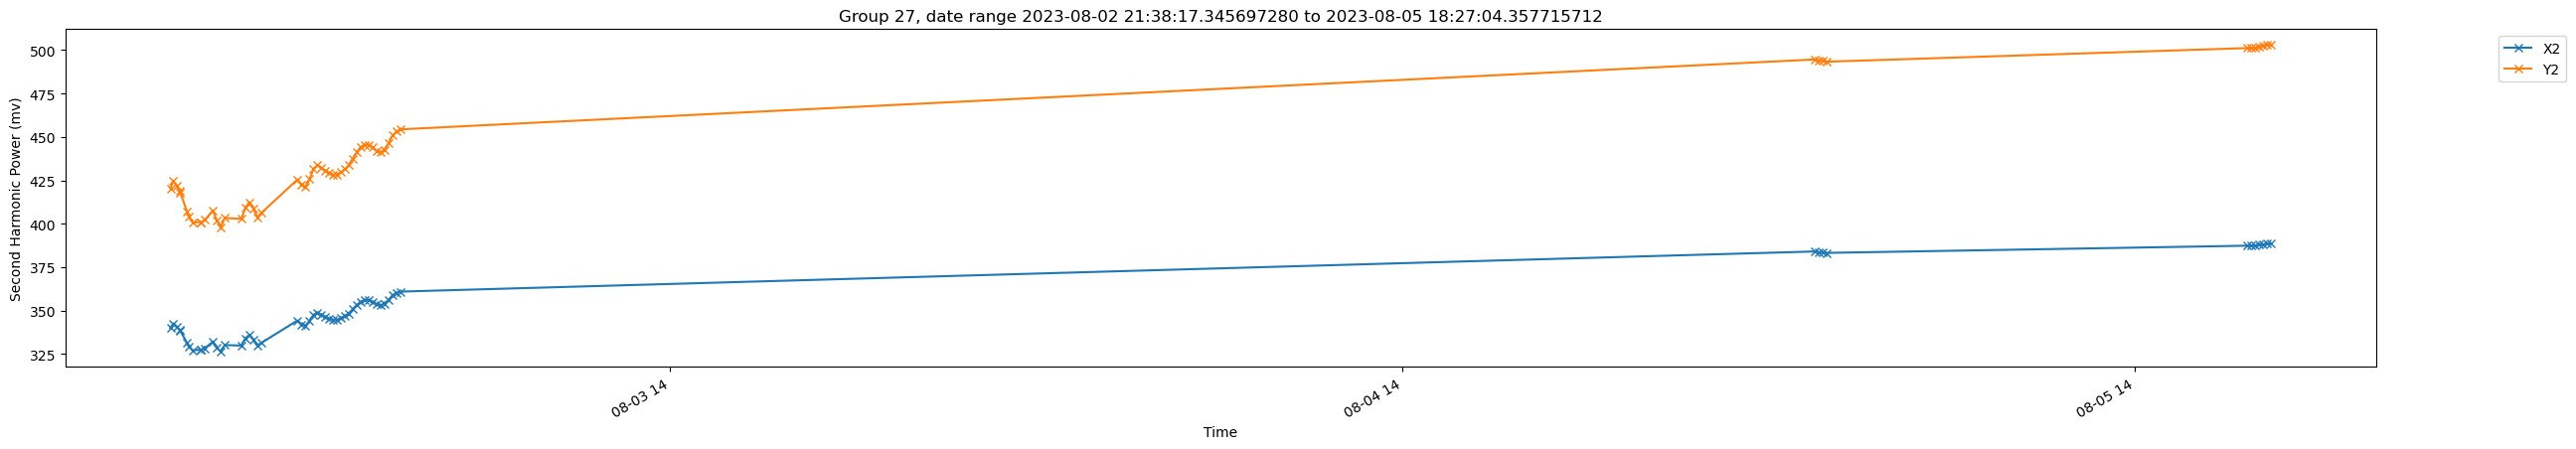

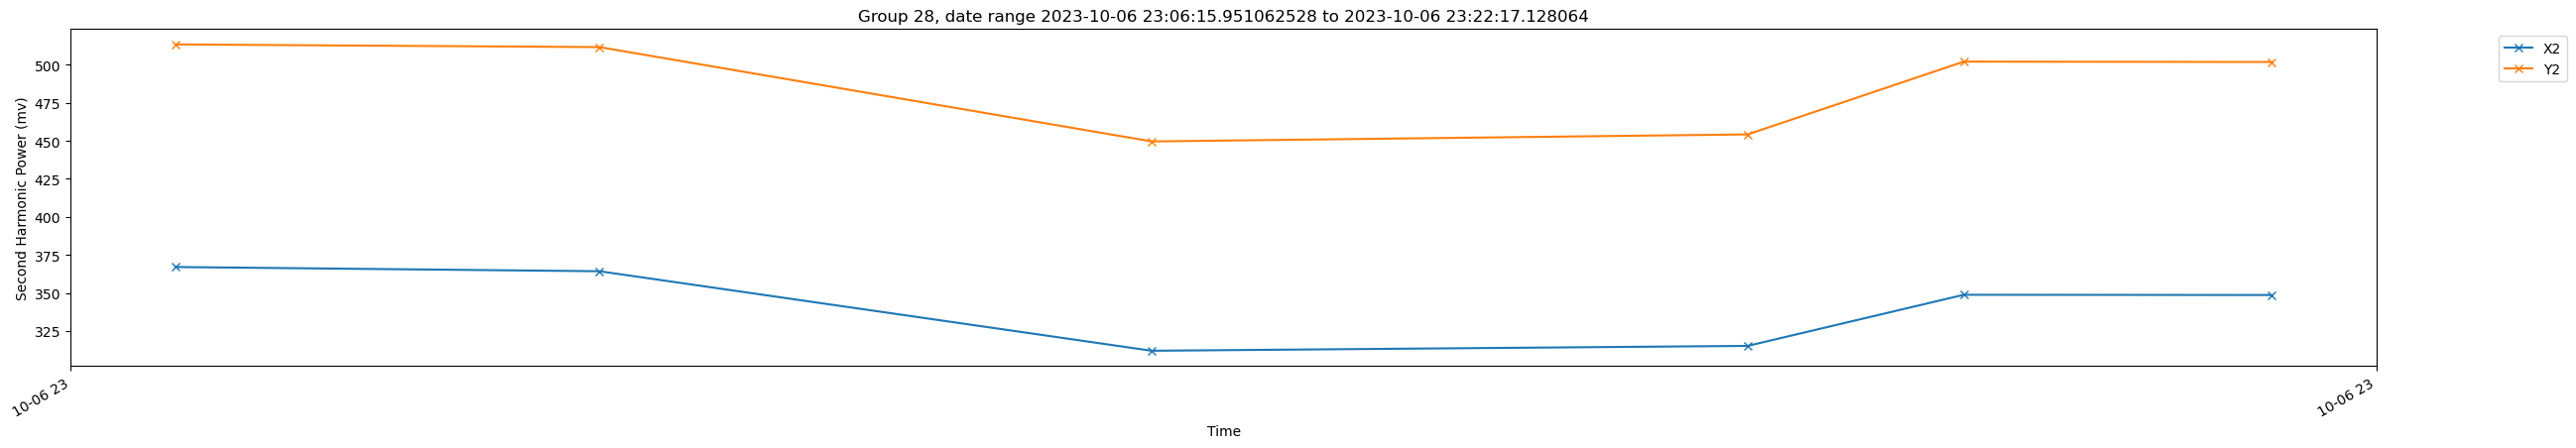

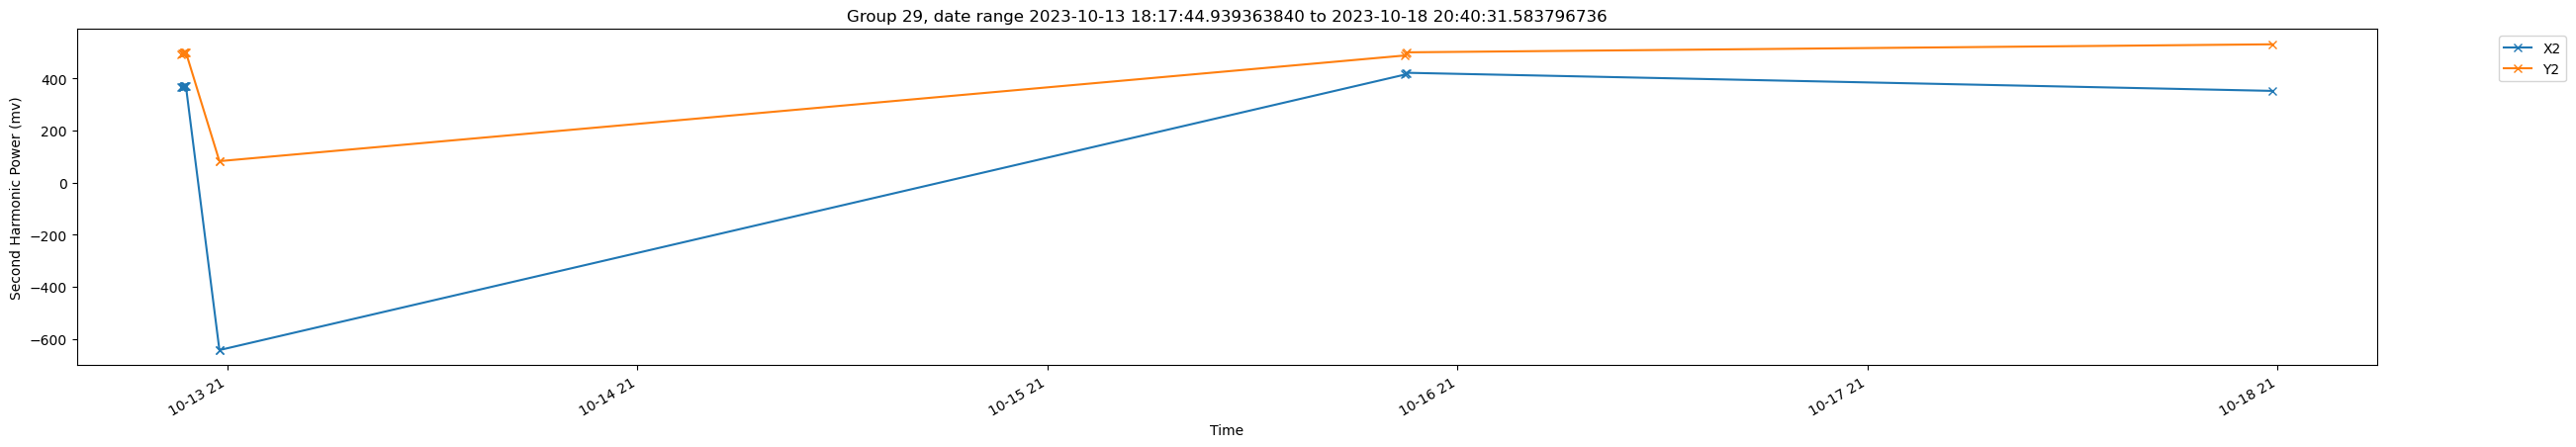

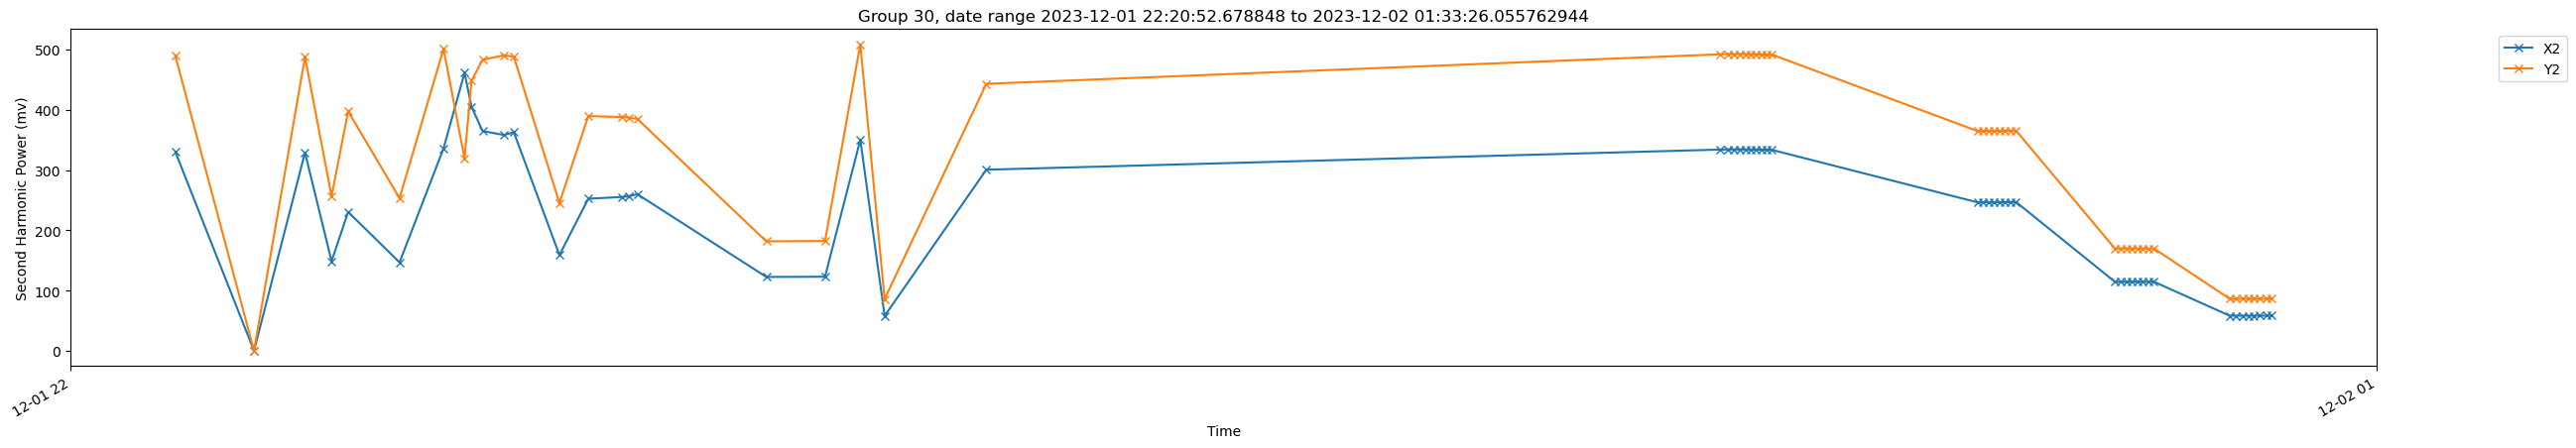

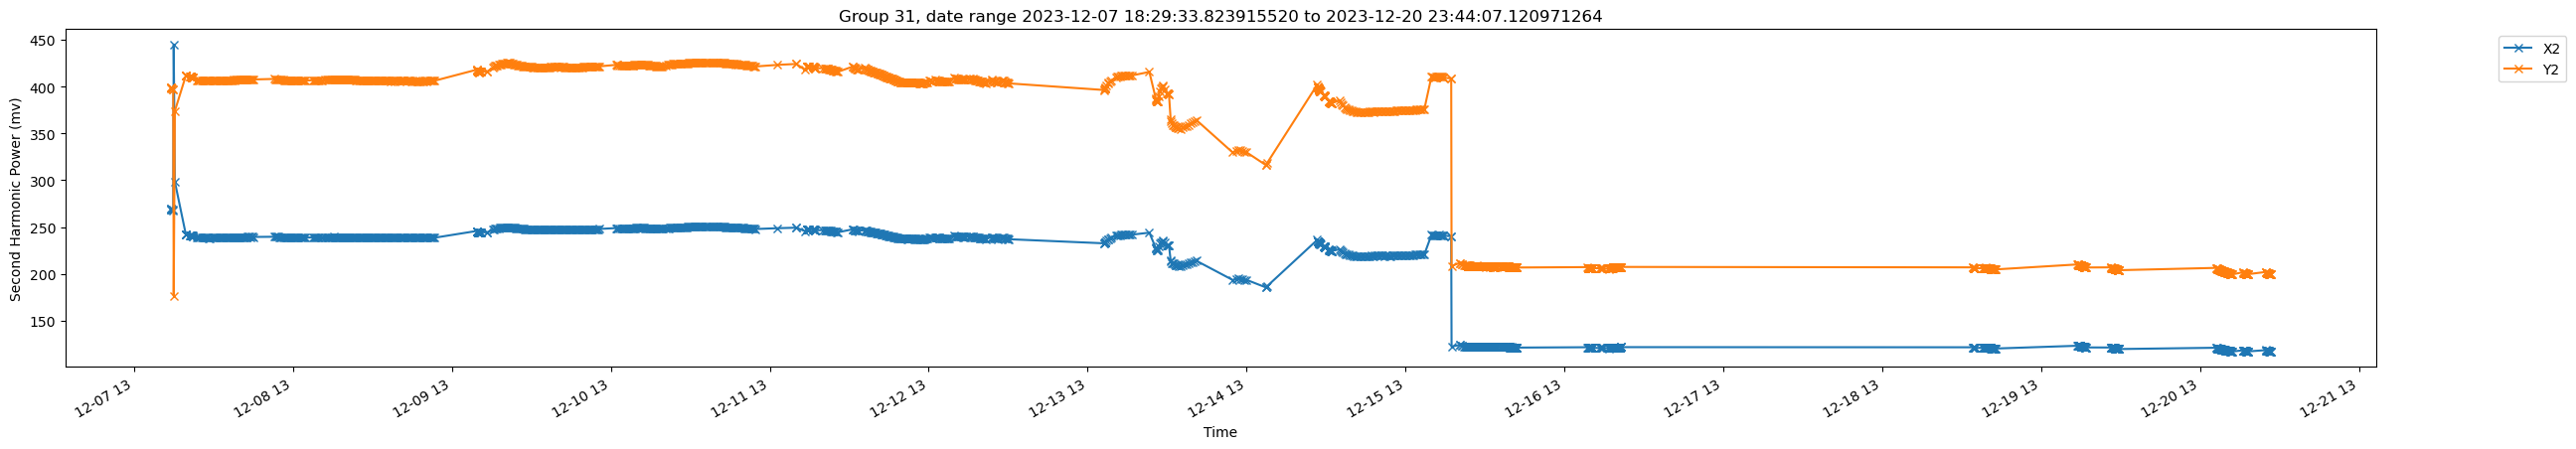

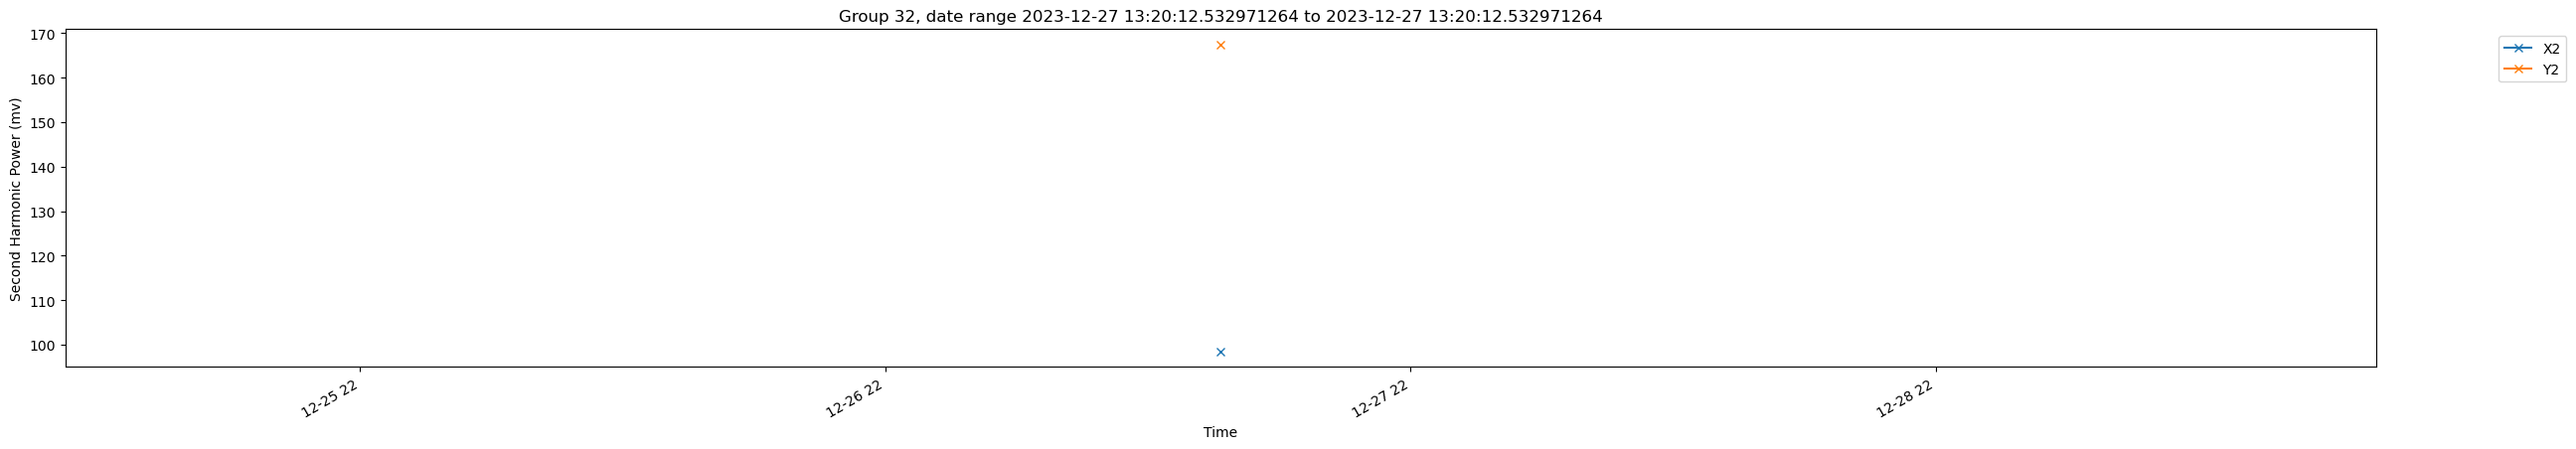

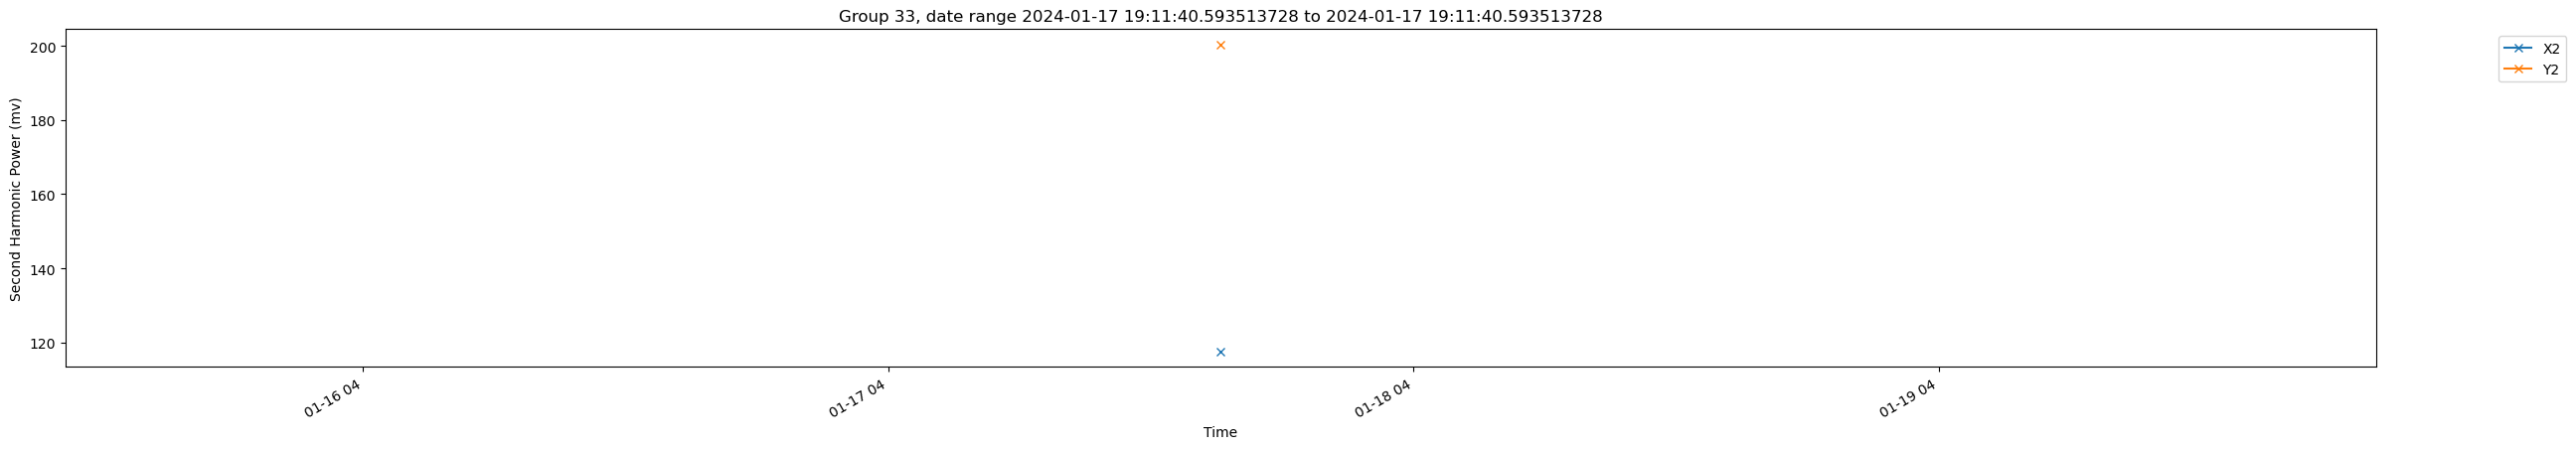

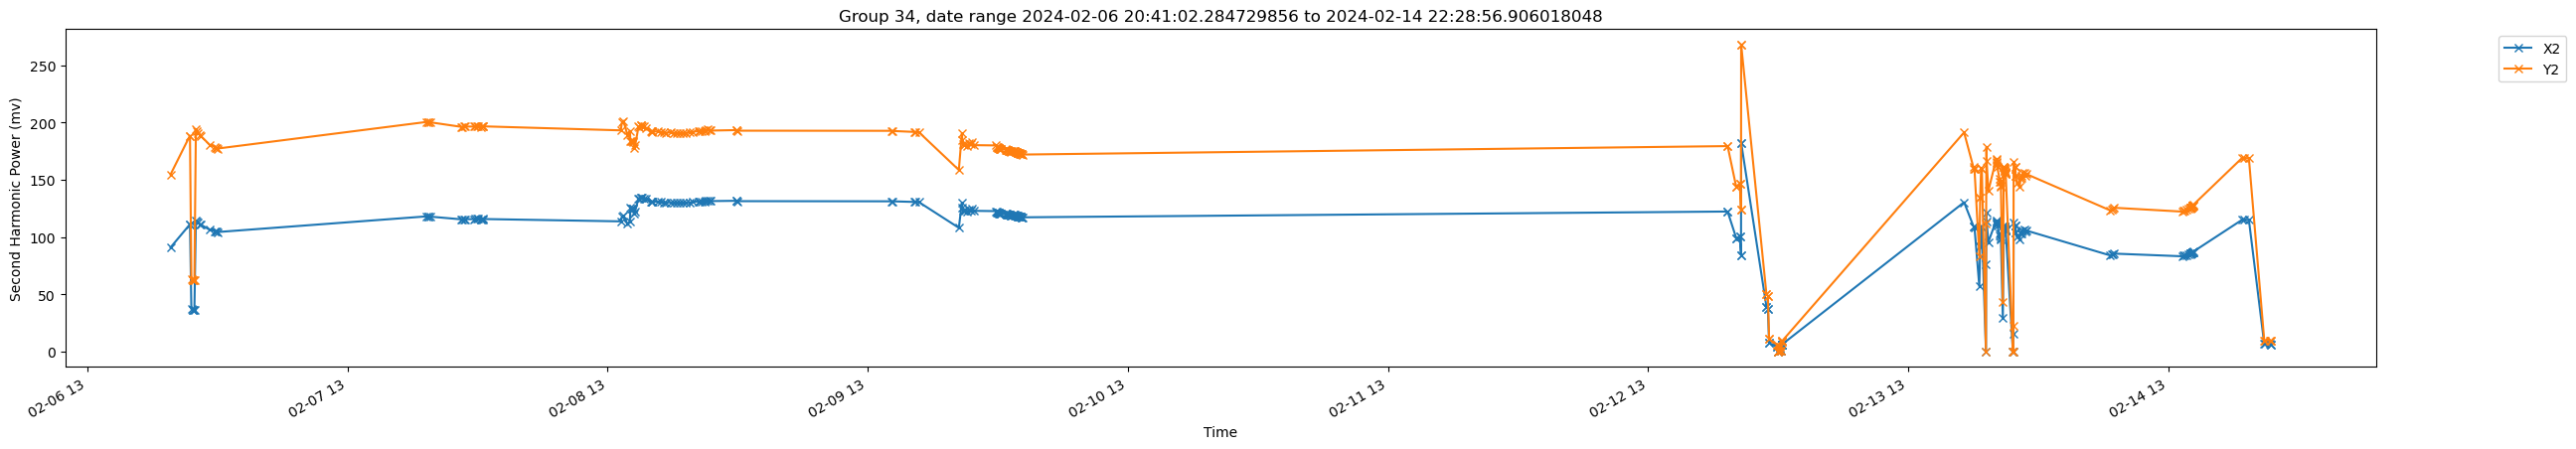

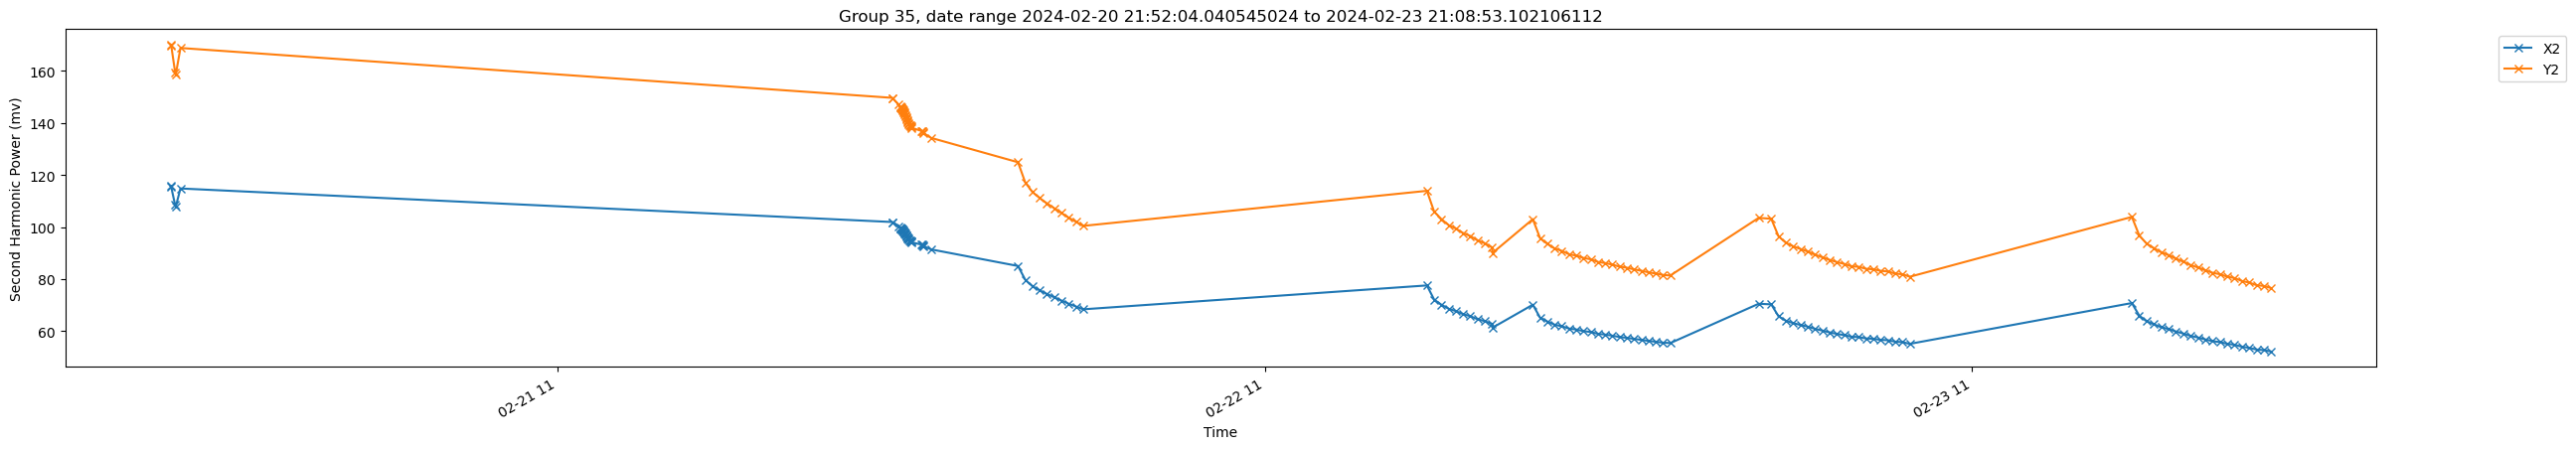

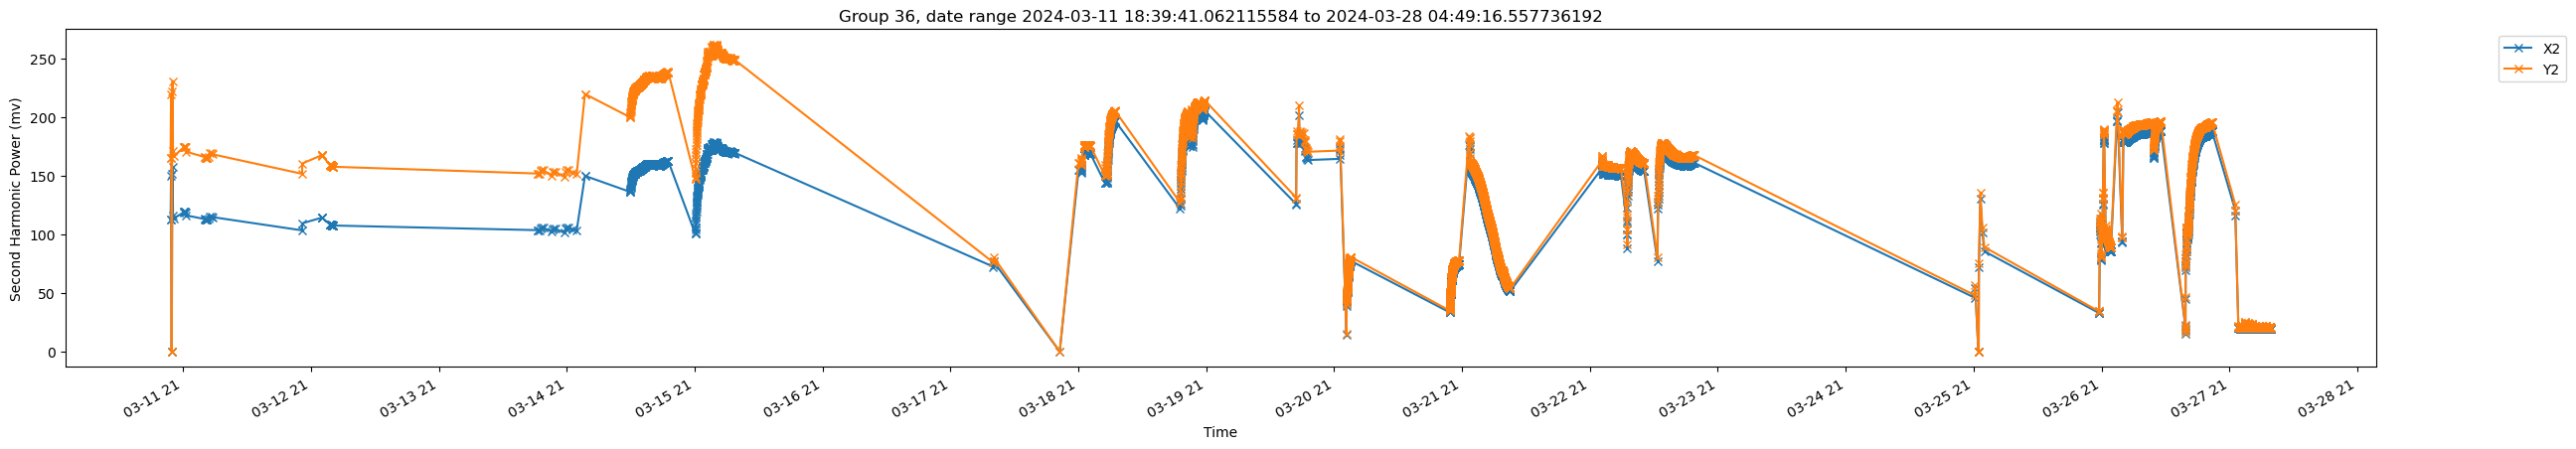

In [128]:
ldp = all_history
ldp["timeDate"] =  pd.to_datetime(ldp['timeModified'], unit='s')
ldp = ldp.sort_values(by='timeDate')
ldp['timeDateDiff'] = ldp.timeDate.diff()
ldp['timeGroup'] = ( ldp['timeDateDiff']> pd.Timedelta( days = 5) ).cumsum()

ldp.timeGroup.values

for groupname, groupdata in ldp.groupby('timeGroup'):
    print(f"groupname is {groupname}, with {groupdata.shape[0]} entries")
    plt.figure(figsize=(30, 5))
    plt.title(f"Group {groupname}, date range {groupdata.timeDate.min()} to {groupdata.timeDate.max()}")
    # print(groupdata.columns)
    sagn.plot_power_for_df( groupdata,hrsPerTick=24)
    plt.savefig(f"./powerGraphs/group_{groupname}.jpg")

# Junk

In [101]:

# # Create a sample dataframe
# df = pd.DataFrame({'Date': ['2022-01-01', '2022-01-03', '2022-01-04', 
#                             '2022-01-22', '2022-01-23','2022-01-23', '2022-01-25', 
#                              '2022-02-01', '2022-02-02', '2022-02-03'],
#                    'Value': [10, 20, 30, 40, 50,
#                              60, 70, 80, 90, 100]})
# print('here is the original dataframe')
# print(df)


# print('here is the broken dataframe')
# # break_dataframe_by_gap(df, 'Date')

# df.groupby('Date').mean()
# df









# def break_dataframe_by_gap(df, date_column, gap_threshold=5):
#     # Convert the date column to datetime type
#     df[date_column] = pd.to_datetime(df[date_column],unit='s')
    
#     # Sort the dataframe by the date column
#     df = df.sort_values(date_column)
    
#     # Calculate the time difference between consecutive dates
#     time_diff = df[date_column].diff()
#         # print('here is the time diff')
#         # print(time_diff)
    
#     # Find the indices where the time difference is greater than 7 days
#     gap_indices = time_diff[time_diff > pd.Timedelta(days=gap_threshold)].index
#     print('here are the gap indices')
#     print(gap_indices)
    
#     # Split the dataframe into multiple dataframes based on the gap indices
#     dfs = []
#     start_index = 0
#     for gap_index in gap_indices:
#         dfs.append(df.iloc[start_index:gap_index])
#         start_index = gap_index
#     dfs.append(df.iloc[start_index:])
    
#     return dfs

